In [1]:
# 1. Import Library
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import os
from src.image_loader import load_mnist_images, load_mnist_labels
from src.image_preprocessor import preprocess_mnist
from src.image_generators import VAE, GAN
from src.text_preprocessor import split_into_sentences
from src.text_generators import PretrainedEmbedder, FullAttnResLLM, LSTMLLM


/mnt/nas-hpg9/eleazartadeo/miniconda3/envs/RAGFramework/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Shape Gambar Data Latih: (60000, 28, 28)
Shape Label Data Latih: (60000,)


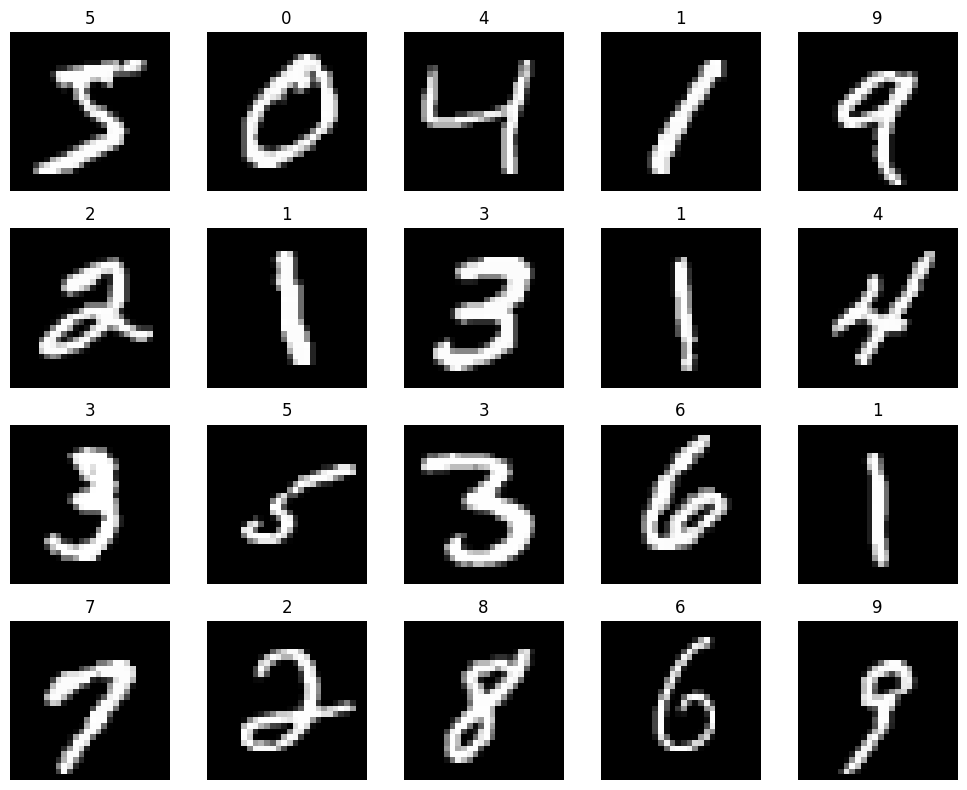

In [3]:
# 3. Load Dataset Vision

# 3.1. Load data latih dan data uji dari file yang sudah di download
x_train = load_mnist_images("dataset/image/train-images-idx3-ubyte")
y_train = load_mnist_labels("dataset/image/train-labels-idx1-ubyte")

x_test = load_mnist_images("dataset/image/t10k-images-idx3-ubyte")
y_test = load_mnist_labels("dataset/image/t10k-labels-idx1-ubyte")

# 3.2. Print shape atau bentuk gambar dan label data latih
print(f"Shape Gambar Data Latih: {x_train.shape}")
print(f"Shape Label Data Latih: {y_train.shape}")

# 3.3. Menunjukkan contoh sampel gambar data latih beserta labelnya
rows = 4
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for i in range(rows * cols):
    r = i // cols
    c = i % cols

    axes[r, c].imshow(x_train[i], cmap='gray')
    axes[r, c].set_title(y_train[i])
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 4. Preprocessing Dataset Vision

# 4.1. Melakukan preprocessing terhadap data latih
x_train, y_train = preprocess_mnist(
    x_train,
    y_train,
    normalize=True,
    flatten=True,
    one_hot=False
)

# 4.2. Menunjukkan contoh sampel gambar data latih beserta labelnya yang sudah di preprocess
print(f"Shape Gambar Data Latih (Preprocessed): {x_train.shape}")
print(f"Shape Label Data Latih (Preprocessed): {y_train.shape}")

# 4.3. Mengubah x_train dan y_train menjadi bentuk tensor untuk dijadikan tensor dataset
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
)

# 4.4. Menjadikan x_train_tensor dan y_train_tensor menjadi tensor dataset
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor,
)

# 4.5. Menjadikan train_dataset menjadi sebuah data loader untuk di training
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)


Shape Gambar Data Latih (Preprocessed): (60000, 784)
Shape Label Data Latih (Preprocessed): (60000,)


### 5. Definisi Model Generatif Vision
Model Generatif Vision adalah jenis kecerdasan buatan (Generative AI) yang dilatih untuk mempelajari pola visual dari data gambar atau video dalam jumlah besar, lalu menggunakan pola tersebut untuk menciptakan konten visual baru yang orisinal dan mirip dengan data latihannya.

### 6. Penjelasan Rumus Model Vision

#### 6.1. Konsep Dasar Generative Model
Model generatif berusaha mempelajari distribusi data:

$$
p(x)
$$

atau distribusi bersyarat:

$$
p(x|c)
$$

- $x$ = data yang ingin dihasilkan, misalnya gambar atau teks, variabel ini merepresentasikan sampel data yang dipelajari atau dihasilkan oleh model generatif.
- $c$ = kondisi, misalnya prompt, label, atau input tertentu, atau berupa informasi tambahan yang digunakan model untuk mengontrol hasil generasi data.
- $p(x)$ = peluang kemunculan data, distribusi probabilitas yang menunjukkan seberapa mungkin suatu data muncul pada dataset.
- $p(x|c)$ = peluang menghasilkan data berdasarkan kondisi tertentu, distribusi probabilitas data dengan mempertimbangkan kondisi atau konteks yang diberikan.

Pada kode PyTorch:

- VAE dan GAN mempelajari distribusi gambar.
- Full Attention Residual Transformer dan LSTM mempelajari distribusi token bahasa.

#### 6.2. Autoencoder

$$
z = f_{\theta}(x)
$$

$$
\hat{x} = g_{\phi}(z)
$$

$$
L = \|x - \hat{x}\|^2
$$

- $x$ = input asli atau data asli yang dimasukkan ke model, misalnya gambar atau sequence token.
- $z$ = latent vector, adalah representasi fitur berdimensi lebih kecil yang menyimpan informasi penting dari input.
- $\hat{x}$ = hasil rekonstruksi, data hasil decoder yang berusaha menyerupai input asli.
- $f_{\theta}$ = encoder, adalah fungsi atau jaringan neural yang mengubah input menjadi latent vector.
- $g_{\phi}$ = decoder, fungsi atau jaringan neural yang mengubah latent vector kembali menjadi data.
- $L$ = reconstruction loss, adalah nilai error yang mengukur seberapa dekat hasil rekonstruksi dengan data asli.

<div align="center">

| Konsep              | Kode PyTorch           |
| ------------------- | ---------------------- |
| Encoder             | `self.encoder(x)`      |
| Decoder             | `self.decoder(z)`      |
| Reconstruction Loss | `F.mse_loss(x_hat, x)` |

</div>

#### 6.3. Variational Autoencoder
$$
q_{\phi}(z|x)
$$

$$
z = \mu + \sigma \cdot \epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = L_{\text{reconstruction}} + L_{KL}
$$

$$
L_{KL} = D_{KL}(q_{\phi}(z|x) \parallel p(z))
$$

- $\mu$ = mean latent, adalah nilai rata-rata distribusi latent yang dipelajari encoder untuk setiap dimensi latent.
- $\sigma$ = standar deviasi latent, nilai penyebaran distribusi latent yang menentukan tingkat variasi sampling.
- $\epsilon$ = noise acak, sampel random dari distribusi normal yang digunakan pada reparameterization trick.
- $q_{\phi}(z|x)$ = distribusi latent dari input, atau distribusi probabilitas latent yang diprediksi encoder berdasarkan input tertentu.
- $p(z)$ = distribusi prior, atau distribusi referensi latent yang digunakan agar ruang latent tetap terstruktur, biasanya normal standar.
- $D_{KL}$ = KL divergence, adalah ukuran perbedaan antara distribusi latent encoder dan distribusi prior.

<div align='center'>

| Konsep             | Kode PyTorch                 |
| ------------------ | ---------------------------- |
| Mean latent        | `mu = self.fc_mu(h)`         |
| Variance latent    | `logvar = self.fc_logvar(h)` |
| Reparameterization | `z = mu + eps * std`         |
| KL Loss            | `kl_loss = ...`              |
</div>

#### 6.4. Generative Adversarial Network (GAN)

$$
\min_G \max_D V(D, G)
$$

$$
V(D,G)=\mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

- $G$ = generator, jaringan neural yang menghasilkan data palsu dari random noise.
- $D$ = discriminator, jaringan neural yang membedakan data asli dan data palsu.
- $x$ = data asli, atau sampel nyata dari dataset yang digunakan saat training.
- $z$ = noise acak, vektor random yang menjadi input generator untuk membuat data baru.
- $G(z)$ = data palsu yang dibuat generator, output generator yang diharapkan menyerupai data asli.
- $D(x)$ = probabilitas data dianggap asli, nilai prediksi discriminator mengenai kemungkinan suatu data berasal dari dataset nyata.

<div align='center'>

| Konsep        | Kode PyTorch                          |
| ------------- | ------------------------------------- |
| Generator     | `self.generator(z)`                   |
| Discriminator | `self.discriminator(real_images)`     |
| Fake image    | `fake_images = self.generate_fake(z)` |
| GAN Loss      | `nn.BCEWithLogitsLoss()`              |

</div>

#### 6.5. Diffusion Model

$$
x_t = \sqrt{\alpha_t} x_0 + \sqrt{1 - \alpha_t}\,\epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = \|\epsilon - \epsilon_{\theta}(x_t, t)\|^2
$$

- $x_0$ = gambar asli.
- $x_t$ = gambar yang sudah diberi noise.
- $\epsilon$ = noise asli.
- $\epsilon_{\theta}$ = noise yang diprediksi model.
- $t$ = timestep, tahapan proses diffusion yang menunjukkan tingkat noise pada data.
- $\alpha_t$ = koefisien noise, parameter yang mengatur proporsi informasi asli dan noise pada timestep tertentu.


In [5]:
# Membuat folder untuk menyimpan semua gambar dan hasil eksperimen (berlaku untuk teks juga)
def get_timestamp() -> str:
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def create_folder(path:str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

run_path = create_folder(f"outputs/run-{get_timestamp()}")

Training VAE-5e-64ld
Epoch [1] | epoch_time: 0.003328 | kl_loss: 0.000088 | loss: 0.070272 | recon_loss: 0.070184
Epoch [2] | epoch_time: 0.003056 | kl_loss: 0.000051 | loss: 0.067548 | recon_loss: 0.067498
Epoch [3] | epoch_time: 0.002957 | kl_loss: 0.000044 | loss: 0.067472 | recon_loss: 0.067429
Epoch [4] | epoch_time: 0.002980 | kl_loss: 0.000037 | loss: 0.067426 | recon_loss: 0.067389
Epoch [5] | epoch_time: 0.002912 | kl_loss: 0.000027 | loss: 0.067389 | recon_loss: 0.067362

=== Training Complete ===
  Total Time: 14.29s (0.24m)
Model saved to: outputs/run-20260511-075038/image/VAE-5e-64ld/checkpoints


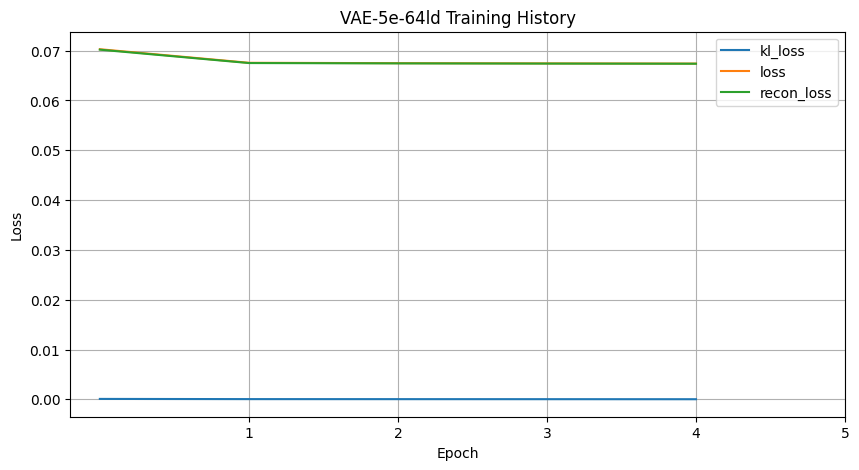

Training VAE-5e-128ld
Epoch [1] | epoch_time: 0.003006 | kl_loss: 0.000381 | loss: 0.070196 | recon_loss: 0.069815
Epoch [2] | epoch_time: 0.003053 | kl_loss: 0.001381 | loss: 0.067211 | recon_loss: 0.065830
Epoch [3] | epoch_time: 0.003029 | kl_loss: 0.001597 | loss: 0.067010 | recon_loss: 0.065413
Epoch [4] | epoch_time: 0.003100 | kl_loss: 0.001583 | loss: 0.067002 | recon_loss: 0.065420
Epoch [5] | epoch_time: 0.003101 | kl_loss: 0.001601 | loss: 0.066941 | recon_loss: 0.065340

=== Training Complete ===
  Total Time: 14.34s (0.24m)
Model saved to: outputs/run-20260511-075038/image/VAE-5e-128ld/checkpoints


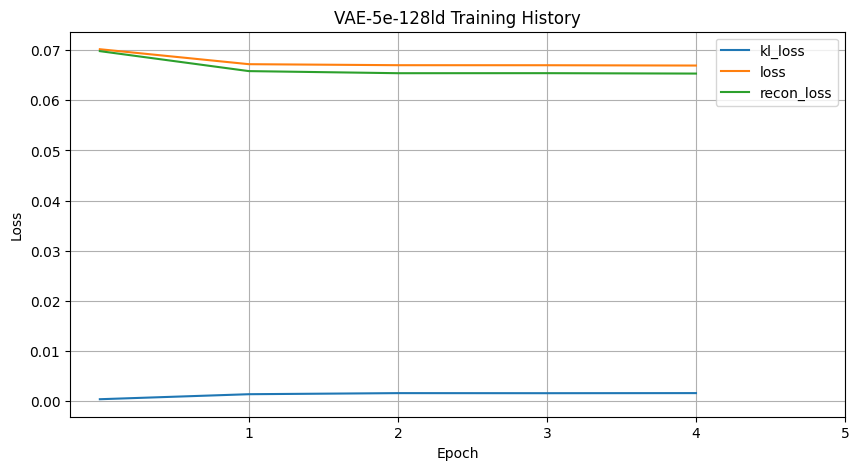

Training VAE-20e-64ld
Epoch [1] | epoch_time: 0.003141 | kl_loss: 0.000097 | loss: 0.070396 | recon_loss: 0.070299
Epoch [2] | epoch_time: 0.003076 | kl_loss: 0.000054 | loss: 0.067550 | recon_loss: 0.067496
Epoch [3] | epoch_time: 0.003086 | kl_loss: 0.000042 | loss: 0.067474 | recon_loss: 0.067431
Epoch [4] | epoch_time: 0.003061 | kl_loss: 0.000028 | loss: 0.067426 | recon_loss: 0.067398
Epoch [5] | epoch_time: 0.003059 | kl_loss: 0.000023 | loss: 0.067385 | recon_loss: 0.067362
Epoch [6] | epoch_time: 0.002963 | kl_loss: 0.000014 | loss: 0.067364 | recon_loss: 0.067350
Epoch [7] | epoch_time: 0.002991 | kl_loss: 0.000011 | loss: 0.067344 | recon_loss: 0.067333
Epoch [8] | epoch_time: 0.003039 | kl_loss: 0.000009 | loss: 0.067332 | recon_loss: 0.067323
Epoch [9] | epoch_time: 0.003015 | kl_loss: 0.000008 | loss: 0.067317 | recon_loss: 0.067309
Epoch [10] | epoch_time: 0.003033 | kl_loss: 0.000008 | loss: 0.067315 | recon_loss: 0.067307
Epoch [11] | epoch_time: 0.003034 | kl_loss: 0.

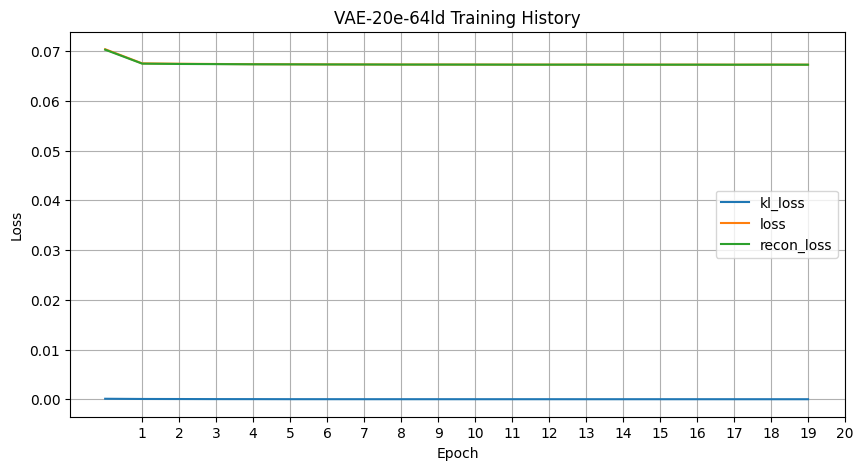

Training VAE-20e-128ld
Epoch [1] | epoch_time: 0.003141 | kl_loss: 0.000370 | loss: 0.070274 | recon_loss: 0.069905
Epoch [2] | epoch_time: 0.003065 | kl_loss: 0.001410 | loss: 0.067195 | recon_loss: 0.065786
Epoch [3] | epoch_time: 0.003041 | kl_loss: 0.001579 | loss: 0.067020 | recon_loss: 0.065442
Epoch [4] | epoch_time: 0.003053 | kl_loss: 0.001569 | loss: 0.066943 | recon_loss: 0.065374
Epoch [5] | epoch_time: 0.003223 | kl_loss: 0.001610 | loss: 0.066929 | recon_loss: 0.065319
Epoch [6] | epoch_time: 0.003069 | kl_loss: 0.001631 | loss: 0.066892 | recon_loss: 0.065261
Epoch [7] | epoch_time: 0.003009 | kl_loss: 0.001619 | loss: 0.066823 | recon_loss: 0.065204
Epoch [8] | epoch_time: 0.003082 | kl_loss: 0.001634 | loss: 0.066873 | recon_loss: 0.065239
Epoch [9] | epoch_time: 0.003063 | kl_loss: 0.001638 | loss: 0.066850 | recon_loss: 0.065212
Epoch [10] | epoch_time: 0.003055 | kl_loss: 0.001675 | loss: 0.066793 | recon_loss: 0.065118
Epoch [11] | epoch_time: 0.003021 | kl_loss: 0

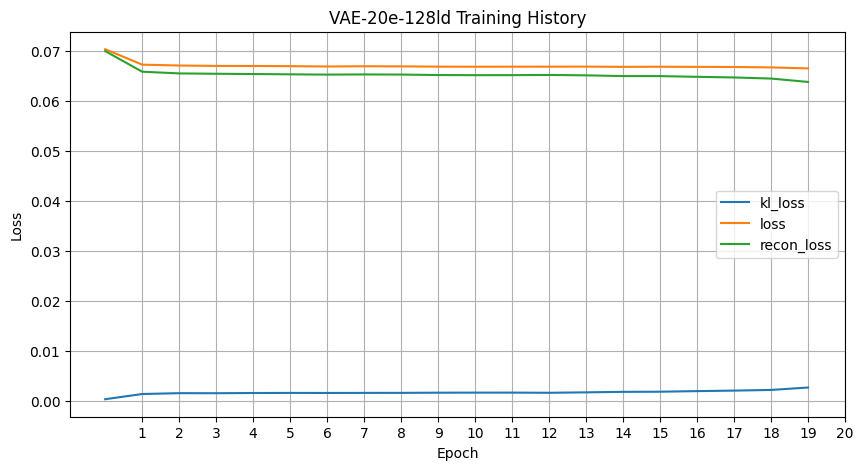

Training GAN-5e-64ld
Epoch [1] | d_loss: 0.325305 | epoch_time: 0.004351 | g_loss: 3.080009
Epoch [2] | d_loss: 0.018716 | epoch_time: 0.004295 | g_loss: 5.909470
Epoch [3] | d_loss: 0.017529 | epoch_time: 0.004366 | g_loss: 5.825154
Epoch [4] | d_loss: 0.012668 | epoch_time: 0.004386 | g_loss: 6.392954
Epoch [5] | d_loss: 0.009716 | epoch_time: 0.004371 | g_loss: 9.290106

=== Training Complete ===
  Total Time: 20.42s (0.34m)
Model saved to: outputs/run-20260511-075038/image/GAN-5e-64ld/checkpoints


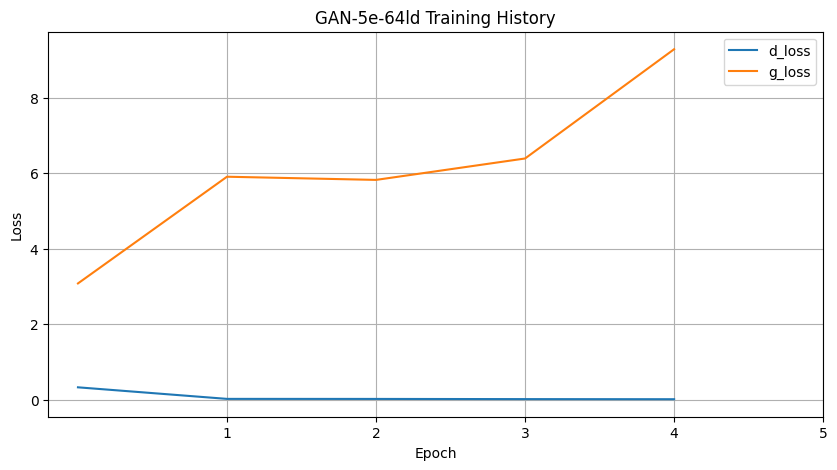

Training GAN-5e-128ld
Epoch [1] | d_loss: 0.272012 | epoch_time: 0.004343 | g_loss: 2.521574
Epoch [2] | d_loss: 0.015911 | epoch_time: 0.004314 | g_loss: 6.181043
Epoch [3] | d_loss: 0.019624 | epoch_time: 0.004353 | g_loss: 5.819093
Epoch [4] | d_loss: 0.015363 | epoch_time: 0.004360 | g_loss: 6.110645
Epoch [5] | d_loss: 0.090284 | epoch_time: 0.004316 | g_loss: 13.427194

=== Training Complete ===
  Total Time: 20.34s (0.34m)
Model saved to: outputs/run-20260511-075038/image/GAN-5e-128ld/checkpoints


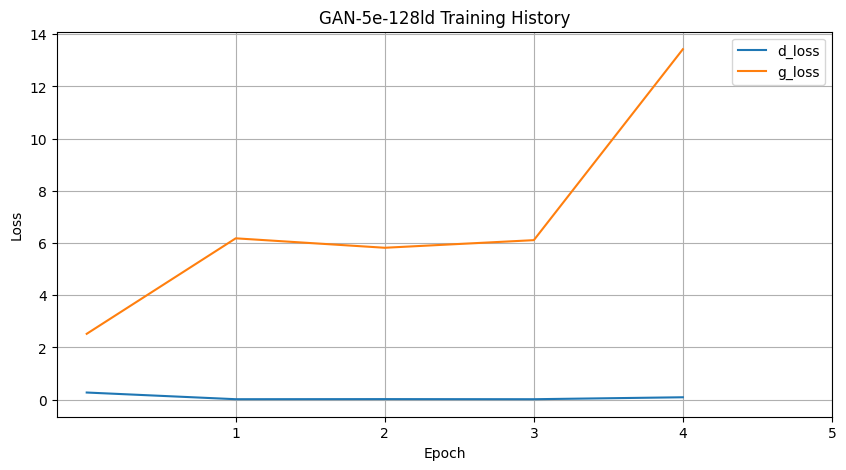

Training GAN-20e-64ld
Epoch [1] | d_loss: 0.288006 | epoch_time: 0.004405 | g_loss: 3.315504
Epoch [2] | d_loss: 0.015202 | epoch_time: 0.004426 | g_loss: 5.915148
Epoch [3] | d_loss: 0.009159 | epoch_time: 0.004321 | g_loss: 6.468173
Epoch [4] | d_loss: 0.006988 | epoch_time: 0.004369 | g_loss: 7.598958
Epoch [5] | d_loss: 0.014301 | epoch_time: 0.004355 | g_loss: 10.808254
Epoch [6] | d_loss: 0.014396 | epoch_time: 0.004272 | g_loss: 8.697709
Epoch [7] | d_loss: 0.005083 | epoch_time: 0.004316 | g_loss: 8.275391
Epoch [8] | d_loss: 0.008515 | epoch_time: 0.004316 | g_loss: 9.185786
Epoch [9] | d_loss: 0.010923 | epoch_time: 0.004276 | g_loss: 9.918796
Epoch [10] | d_loss: 0.011730 | epoch_time: 0.004314 | g_loss: 11.818290
Epoch [11] | d_loss: 0.008091 | epoch_time: 0.004300 | g_loss: 9.760427
Epoch [12] | d_loss: 0.012720 | epoch_time: 0.004242 | g_loss: 12.400375
Epoch [13] | d_loss: 0.012880 | epoch_time: 0.004269 | g_loss: 15.268950
Epoch [14] | d_loss: 0.011776 | epoch_time: 0.0

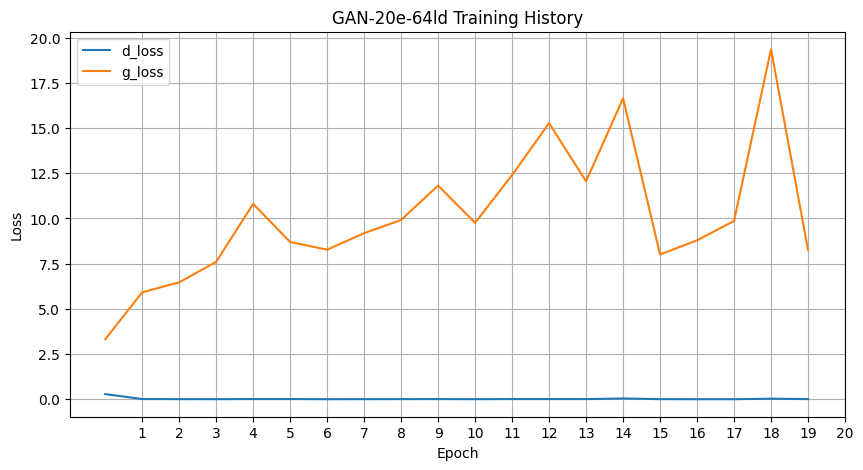

Training GAN-20e-128ld
Epoch [1] | d_loss: 0.334651 | epoch_time: 0.004451 | g_loss: 3.054554
Epoch [2] | d_loss: 0.023223 | epoch_time: 0.004385 | g_loss: 5.777728
Epoch [3] | d_loss: 0.012349 | epoch_time: 0.004395 | g_loss: 7.365716
Epoch [4] | d_loss: 0.009616 | epoch_time: 0.004478 | g_loss: 7.037499
Epoch [5] | d_loss: 0.008586 | epoch_time: 0.004461 | g_loss: 7.875612
Epoch [6] | d_loss: 0.013119 | epoch_time: 0.004408 | g_loss: 9.136139
Epoch [7] | d_loss: 0.006014 | epoch_time: 0.004397 | g_loss: 9.574843
Epoch [8] | d_loss: 0.011964 | epoch_time: 0.004367 | g_loss: 10.883541
Epoch [9] | d_loss: 0.004846 | epoch_time: 0.004417 | g_loss: 8.184881
Epoch [10] | d_loss: 0.005283 | epoch_time: 0.004433 | g_loss: 11.134526
Epoch [11] | d_loss: 0.009630 | epoch_time: 0.004481 | g_loss: 11.248693
Epoch [12] | d_loss: 0.013340 | epoch_time: 0.004367 | g_loss: 9.939210
Epoch [13] | d_loss: 0.006976 | epoch_time: 0.004379 | g_loss: 12.081631
Epoch [14] | d_loss: 0.016115 | epoch_time: 0.

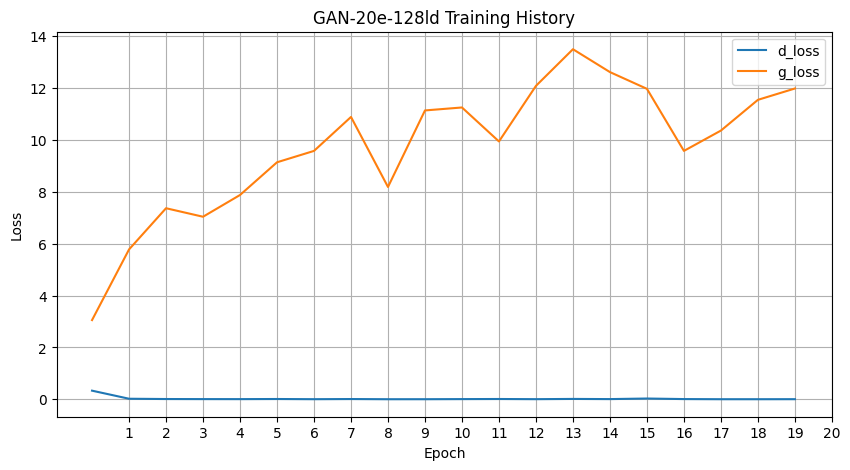

In [6]:
# 7. Training Model Vision

# 7.1. Membuat dictionary model yang digunakan beserta confignya

# 7.1.1. Variabel konstan untuk mempermudah edit eskperimen bersamaan
E5 = 5
E20 = 20
LD64 = 64
LD128 = 128

# 7.1.2. Dictionary model yang digunakan beserta confignya berdasarkan variabel konstan yang sudah ditetapkan
models = {
        f"VAE-{E5}e-{LD64}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E5,
            },
        },
        f"VAE-{E5}e-{LD128}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E5,
            },
        },
        f"VAE-{E20}e-{LD64}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E20,
            },
        },
        f"VAE-{E20}e-{LD128}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E20,
            },
        },
        f"GAN-{E5}e-{LD64}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E5,
            }
        },
        f"GAN-{E5}e-{LD128}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E5,
            }
        },
        f"GAN-{E20}e-{LD64}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E20,
            }
        },
        f"GAN-{E20}e-{LD128}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E20,
            }
        },
    }

# 7.2. Membuat dictionary history kosong untuk menyimpan semua hasil training eksperimen image generation
histories = {}

# 7.3.1. Membuat folder untuk menyimpan semua gambar dan hasil eksperimen khusus eksperimen image
image_path = create_folder(f"{run_path}/image")

# 7.4. Melakukan proses training dan menyimpan hasil model beserta historynya kedalam dictionary histories
for exp_name, exp_data in models.items():

    # 7.4.1. Ekstrak model dan konfigurasi dari dictionary yang sudah dibuat sebelumnya
    model_class = exp_data["model"]
    config = exp_data["config"]

    # 7.4.2. Instansiasi model
    model = model_class(
        input_dim=x_train.shape[1],
        latent_dim=config["latent_dim"],
        hidden_dim=config["hidden_dim"],
        device=device
    ).to(device)

    # 7.4.3. Melakukan proses training dengan menunjukkan proses epoch beserta waktu dan lossnya.
    print("=" * 75)
    print(f"Training {exp_name}")
    print("=" * 75)
    history = model.train_model(
        dataloader=train_loader,
        epochs=config["epochs"],
        verbose=True,
        save_path=f"{image_path}/{exp_name}/checkpoints",
    )

    # 7.4.4. Visualisasi grafik training history (disimpan juga untuk dimasukkan dalam laporan)
    history.plot(
        title=f"{exp_name} Training History",
        save_path=f"{image_path}/{exp_name}/{exp_name}_training_history.png"
    )

    # 7.4.5. Menyimpan hasil training eksperimen image generation terhadap masing masing model
    histories[exp_name] = {
        "model": model,
        "history": history,
        "config": config,
    }


In [7]:
# 8. Generate Gambar Baru

# 8.1. Menentukan jumlah baris dan kolom visualisasi
rows = 4
cols = 5

# 8.2. Dictionary untuk menyimpan semua hasil generasi gambar
all_samples = {}

# 8.2. Melakukan generasi gambar masing masing yang sudah di untuk semua hasil generasi gambar
for exp_name, result in histories.items():

    model = result['model']

    samples = model.generate(rows * cols)

    print(f"Generated {len(samples)} images from {exp_name}")

    all_samples[exp_name] = samples

Generated 20 images from VAE-5e-64ld
Generated 20 images from VAE-5e-128ld
Generated 20 images from VAE-20e-64ld
Generated 20 images from VAE-20e-128ld
Generated 20 images from GAN-5e-64ld
Generated 20 images from GAN-5e-128ld
Generated 20 images from GAN-20e-64ld
Generated 20 images from GAN-20e-128ld


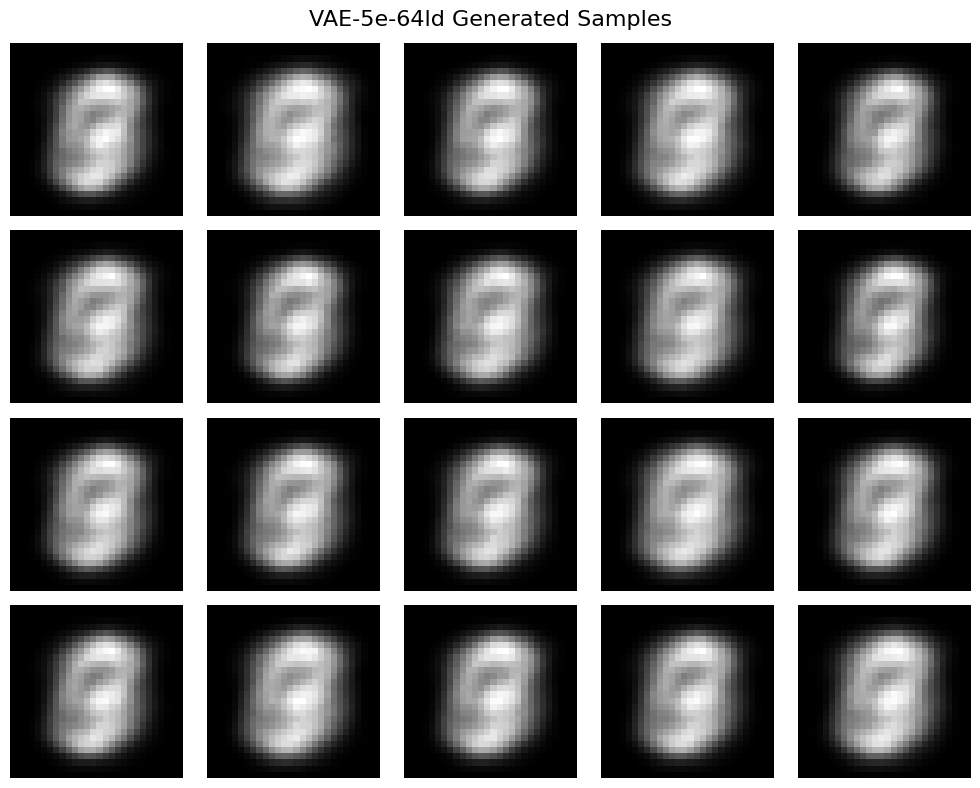

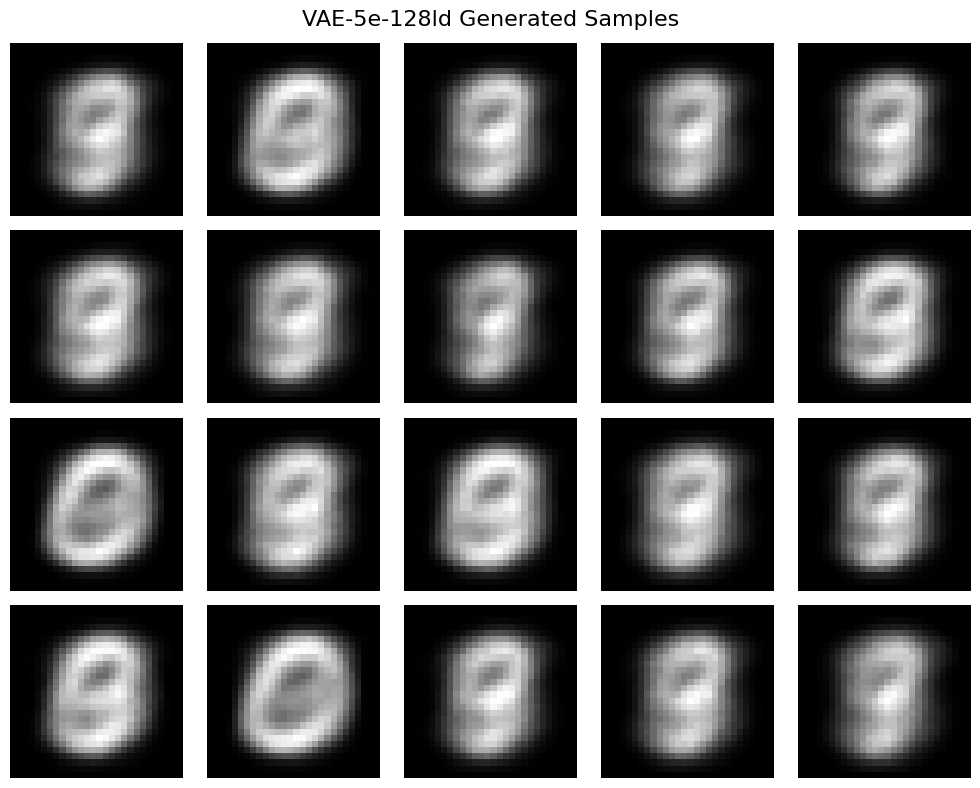

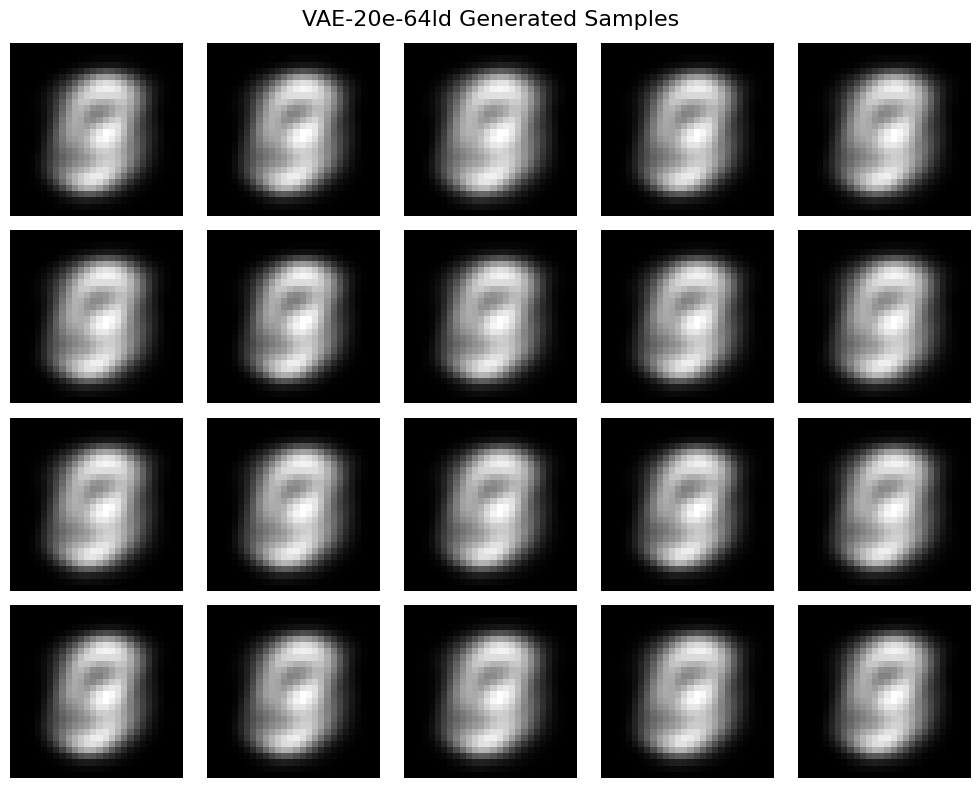

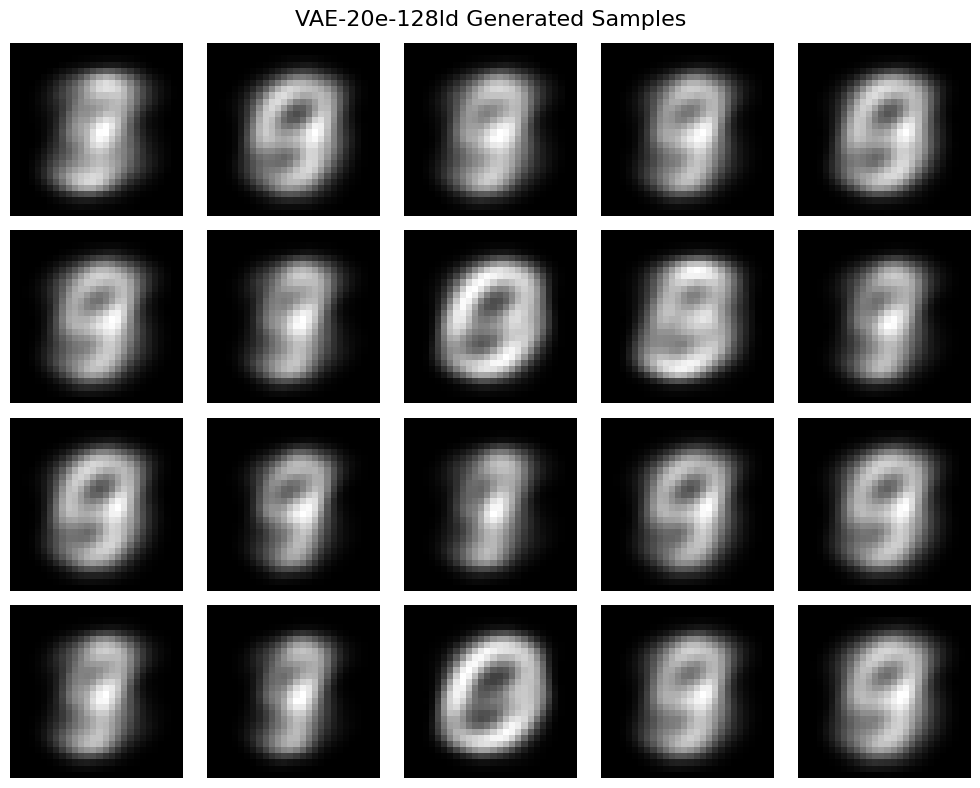

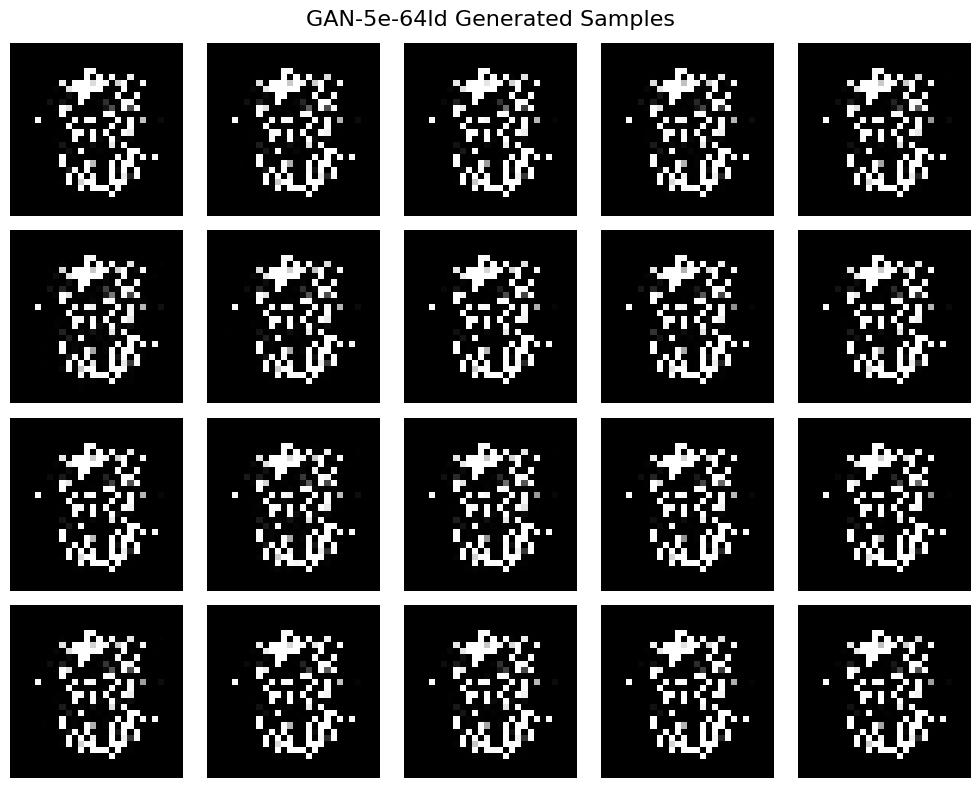

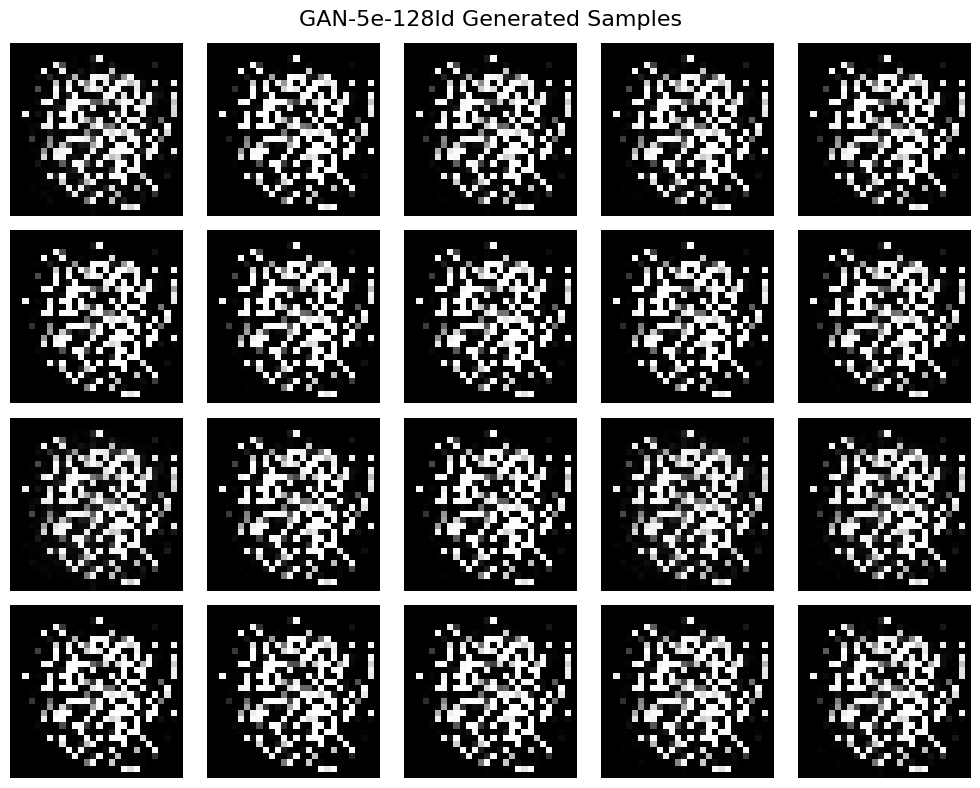

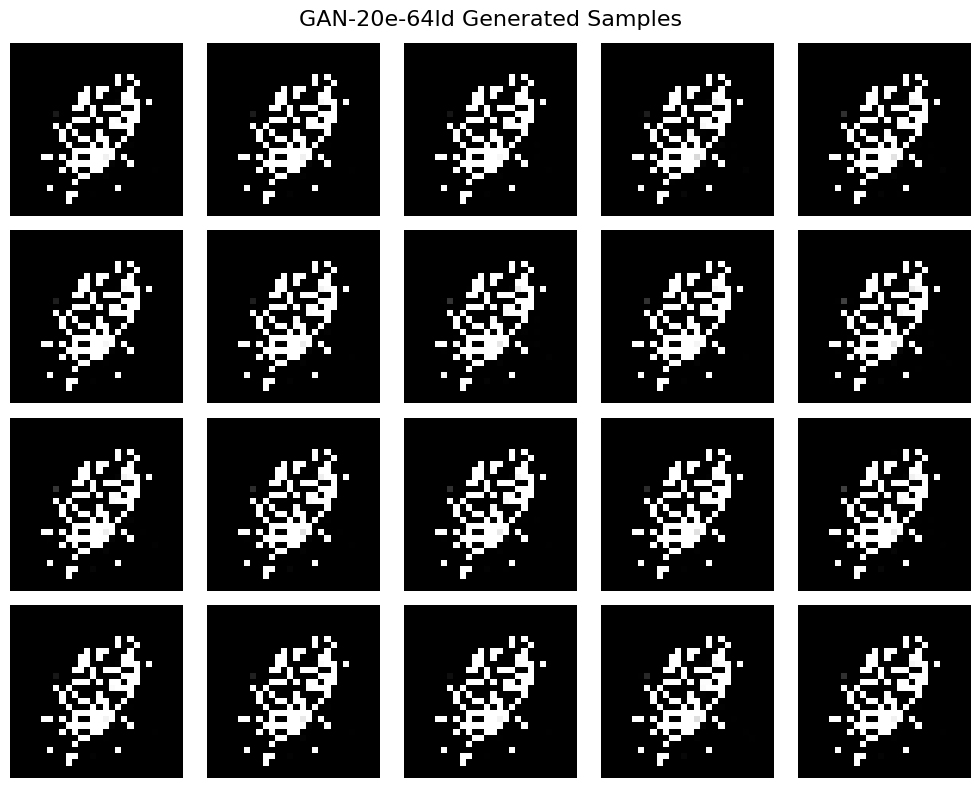

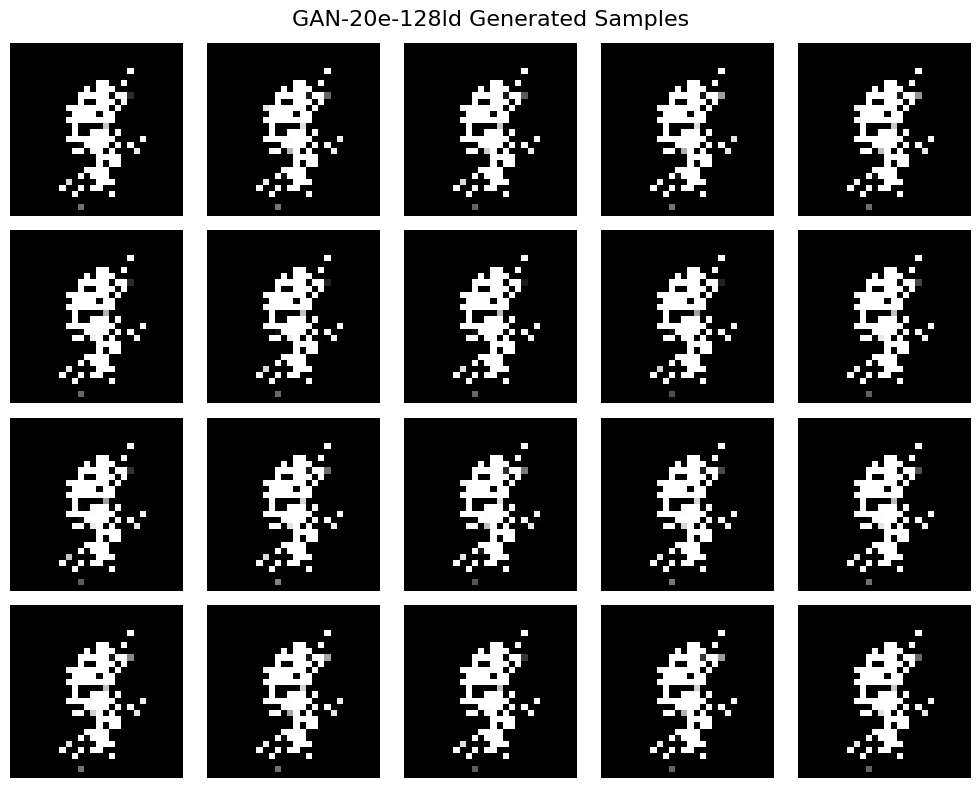

In [8]:
# 9. Visualisasi Hasil Vision

# 9.1. Iterasi untuk setiap model yang digunakan beserta sampel yang digenerasi sesuai dengan ketentuan jumlah sampel
# yang sudah didefinisikan sebelumnya, menampilkan gambar hasil generasi untuk perbandingan beserta menyimpannya untuk laporan

generated_image_path = create_folder(f"{image_path}/generated")
for model_name, samples in all_samples.items():
    fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

    for i in range(rows*cols):
        r = i // cols
        c = i % cols

        axes[r, c].imshow(samples[i][0], cmap="gray")
        axes[r, c].axis("off")
        
    fig.suptitle(f"{model_name} Generated Samples", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{generated_image_path}/{model_name}-generated-samples.png", dpi=300, bbox_inches="tight")
    plt.show()


In [9]:
# 10. Load Dataset Text

# 10.1. Load dataset text dari csv
df = pd.read_csv("dataset/text/wikipedia_id-clean.csv")

# 10.2. Validasi dataset yang sudah di load
print("Kolom:", df.columns.tolist())
print("Sample judul:", df["title"].iloc[0])
print("Panjang teks pertama:", len(str(df["text"].iloc[0])))

Kolom: ['id', 'parent_id', 'timestamp', 'hash', 'title', 'text']
Sample judul: Asam deoksiribonukleat
Panjang teks pertama: 21763


In [10]:
# 11. Preprocessing Text

# 11.1. Membuat penyimpanan untuk data per topik wiki indonesia
data_per_topic = {}

# 11.2. Menentukan seberapa banyak topik yang ingin digunakan sebagai data latih
N_TOPICS = 50
for idx, row in df.head(N_TOPICS).iterrows():
    title = str(row["title"]).strip()
    text = str(row["text"])
    
    # 11.3. Skip judul kosong atau terlalu pendek
    if not title or len(title) < 3:
        continue
    
    # 11.4. Split kalimat
    sentences = split_into_sentences(text)
    
    # 11.5. Simpan hanya jika ada minimal 3 kalimat
    if len(sentences) >= 3:
        data_per_topic[title] = sentences

# 11.6. Cek jumlah total topik yang digunakan untuk data latih, beserta kategori topiknya
print(f"\nTotal topik: {len(data_per_topic)}")
print(f"Sample topik: {list(data_per_topic.keys())[:5]}")

# 11.7. Mengubah dari kalimat per topic menjadi 1 list of kalimat - kalimat
all_sentences = [
    sentence 
    for sentences in data_per_topic.values() 
    for sentence in sentences
]

# 11.8. Cek total kalimat dari seluruh topik yang digunakan untuk data latih
total_kalimat = len(all_sentences)
print(f"Total kalimat dari semua topik: {total_kalimat}")

# 11.9. Cek semua kalimat yang nantinya digunakan untuk data latih
for sentence in all_sentences:
    print(sentence)


Total topik: 49
Sample topik: ['Asam deoksiribonukleat', 'Anwar Sadat', 'Azhar Mansor', 'Arkeologi', 'Antropologi']
Total kalimat dari semua topik: 5332
Asam deoksiribonukleat, lebih dikenal dengan singkatan DNA (bahasa Inggris: deoxyribonucleic acid), adalah salah satu jenis asam nukleat yang memiliki kemampuan pewarisan sifat.
Keberadaan asam deoksiribonukleat ditemukan di dalam nukleoprotein yang membentuk inti sel.
James Dewey Watson dan Francis Crick merupakan ilmuwan pertama yang mengajukan model struktur DNA pada tahun 1953 dengan bentuk pilinan ganda.
Setiap DNA tersusun dari dua buah rantai polinukleotida.
DNA merupakan sejenis biomolekul yang menyimpan dan menyandi instruksi-instruksi genetika setiap organisme dan banyak jenis virus.
Instruksi-instruksi genetika ini berperan penting dalam pertumbuhan, perkembangan, dan fungsi organisme dan virus.
DNA merupakan asam nukleat; bersamaan dengan protein dan karbohidrat, asam nukleat adalah makromolekul esensial bagi seluruh makhl

### 12. Definisi Model Generatif Text
Model generatif teks adalah jenis kecerdasan buatan (AI) yang dirancang untuk mempelajari pola, struktur, dan hubungan dalam data teks pelatihan, kemudian menggunakan pengetahuan tersebut untuk menghasilkan konten teks baru yang orisinal, kontekstual, dan mirip dengan data aslinya.

### 13. Penjelasan Rumus Model Text
#### 13.1. Text Generation

Text generation dilakukan dengan memprediksi token satu per satu:

$$
p(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, x_2, ..., x_{t-1})
$$

- $x_t$ = token pada posisi ke-$t$, yaitu token yang sedang diprediksi model.
- $x_1, ..., x_{t-1}$ = token sebelumnya, yaitu konteks sequence yang digunakan untuk memprediksi token berikutnya.
- $T$ = panjang sequence token yang dihasilkan model.
- Model memprediksi token berikutnya berdasarkan token sebelumnya.

<div align="center">

| Konsep                    | Kode PyTorch                         |
| ------------------------- | ------------------------------------ |
| Token Embedding           | `self.token_embedding(input_ids)`    |
| Next Token Prediction     | `target_ids = tokens[idx + 1 : ...]` |
| Autoregressive Generation | `generated = torch.cat(...)`         |
| Token Sampling            | `torch.multinomial(...)`             |

</div>

#### 13.2. Self-Attention Transformer

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- $Q$ = query, representasi token yang digunakan untuk mencari informasi relevan dari token lain.
- $K$ = key, representasi token yang digunakan sebagai acuan pencocokan attention.
- $V$ = value, representasi informasi token yang akan dikombinasikan berdasarkan attention score.
- $d_k$ = dimensi key, jumlah dimensi pada vector key yang digunakan untuk normalisasi attention score.
- $\text{softmax}$ = mengubah skor menjadi bobot perhatian.

<div align="center">

| Konsep            | Kode PyTorch                               |
| ----------------- | ------------------------------------------ |
| Query Projection  | `self.q_proj(h_norm)`                      |
| Key Projection    | `self.k_proj(h_norm)`                      |
| Value Projection  | `self.v_proj(h_norm)`                      |
| Attention Score   | `torch.matmul(Q, K_seq.transpose(-2, -1))` |
| Attention Softmax | `F.softmax(scores, dim=-1)`                |

</div>


#### 13.3. Cross Entropy Loss untuk Text Generation

$$
L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

- $L$ = nilai loss, yaitu error antara prediksi model dan target sebenarnya.
- $y_i$ = token target sebenarnya.
- $\hat{y}_i$ = probabilitas token hasil prediksi.
- $N$ = jumlah token atau vocabulary class.

<div align="center">

| Konsep         | Kode PyTorch                          |
| -------------- | ------------------------------------- |
| Cross Entropy  | `F.cross_entropy(...)`                |
| Ignore Padding | `ignore_index=pad_token_id`           |
| Token Logits   | `logits.reshape(-1, logits.size(-1))` |


</div>

In [11]:
# Membuat folder untuk menyimpan semua gambar dan hasil eksperimen khusus eksperimen text
text_path = create_folder(f"{run_path}/text")


[1] Initializing Pretrained Embedder...
Loading embedder: LazarusNLP/all-indo-e5-small-v4

[2] Training FullAttnResLLM
Auto-detected dim from embedder: 512
Parameters: 135,122,560
Total tokens: 195396
Epoch 1/5 | Batch 5 | Loss: 12.415745
Epoch 1/5 | Batch 10 | Loss: 12.409909
Epoch 1/5 | Batch 15 | Loss: 12.405787
Epoch 1/5 | Batch 20 | Loss: 12.397505
Epoch 1/5 | Batch 25 | Loss: 12.392321
Epoch 1/5 | Batch 30 | Loss: 12.385531
Epoch 1/5 | Batch 35 | Loss: 12.381986
Epoch 1/5 | Batch 40 | Loss: 12.374138
Epoch 1/5 | Batch 45 | Loss: 12.367746
Epoch 1/5 | Batch 50 | Loss: 12.365933
Epoch 1/5 | Batch 55 | Loss: 12.355483
Epoch 1/5 | Batch 60 | Loss: 12.351333
Epoch 1/5 | Batch 65 | Loss: 12.347850
Epoch 1/5 | Batch 70 | Loss: 12.338257
Epoch 1/5 | Batch 75 | Loss: 12.332891
Epoch 1/5 | Batch 80 | Loss: 12.324888
Epoch 1/5 | Batch 85 | Loss: 12.321321
Epoch 1/5 | Batch 90 | Loss: 12.317081
Epoch 1/5 | Batch 95 | Loss: 12.313896
Epoch 1/5 | Batch 100 | Loss: 12.302847
Epoch 1/5 | Batch 

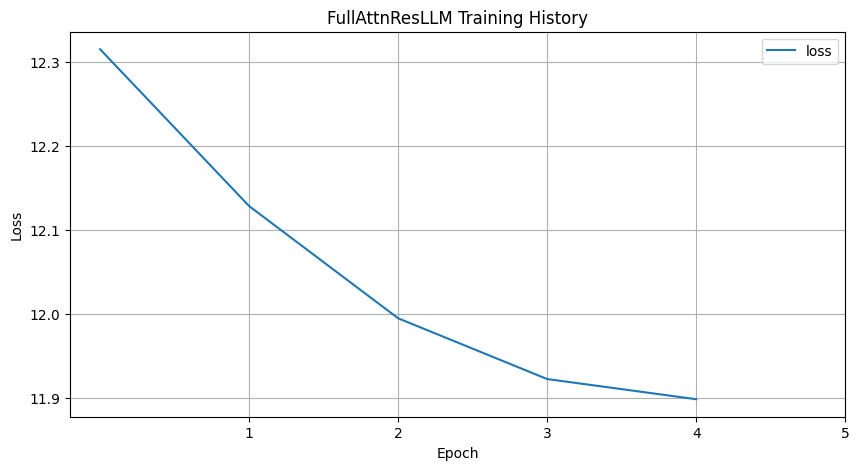


[3] Training LSTMLLM
Auto-detected dim from embedder: 512
Parameters: 126,715,520
Total tokens: 195396
Epoch 1/5 | Batch 5 | Loss: 12.427965
Epoch 1/5 | Batch 10 | Loss: 12.427266
Epoch 1/5 | Batch 15 | Loss: 12.426121
Epoch 1/5 | Batch 20 | Loss: 12.424105
Epoch 1/5 | Batch 25 | Loss: 12.419389
Epoch 1/5 | Batch 30 | Loss: 12.409357
Epoch 1/5 | Batch 35 | Loss: 12.388219
Epoch 1/5 | Batch 40 | Loss: 12.335985
Epoch 1/5 | Batch 45 | Loss: 12.224726
Epoch 1/5 | Batch 50 | Loss: 12.069945
Epoch 1/5 | Batch 55 | Loss: 11.999903
Epoch 1/5 | Batch 60 | Loss: 11.917999
Epoch 1/5 | Batch 65 | Loss: 11.936540
Epoch 1/5 | Batch 70 | Loss: 11.847822
Epoch 1/5 | Batch 75 | Loss: 11.887255
Epoch 1/5 | Batch 80 | Loss: 11.835516
Epoch 1/5 | Batch 85 | Loss: 11.790538
Epoch 1/5 | Batch 90 | Loss: 11.746661
Epoch 1/5 | Batch 95 | Loss: 11.749363
Epoch 1/5 | Batch 100 | Loss: 11.781456
Epoch 1/5 | Batch 105 | Loss: 11.685552
Epoch 1/5 | Batch 110 | Loss: 11.667865
Epoch 1/5 | Batch 115 | Loss: 11.689

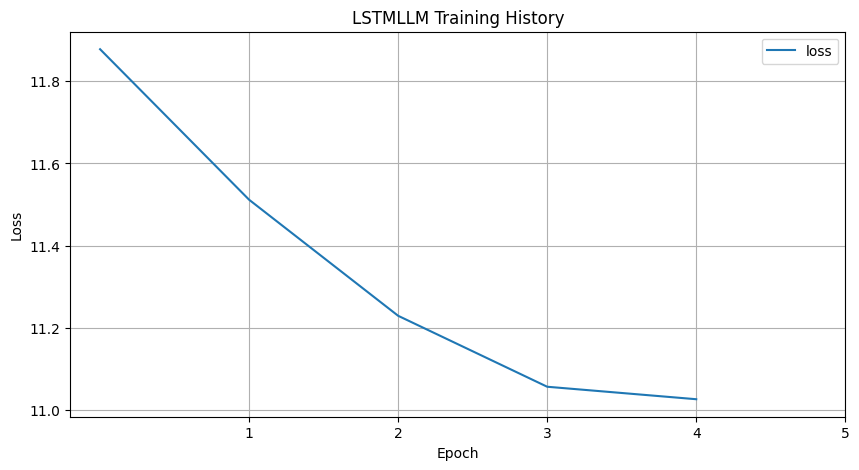

In [12]:
# 14. Training Model Text

# 14.1. Variabel konstan untuk mempermudah edit eskperimen bersamaan
EPOCHS = 5
DIM = 512
CTX_SIZE = 8
BATCH_SIZE = 1024
LR = 1e-4

# 14.2. Inisiasi embedder pretrained yang digunakan dalam training LLM yang dibuat
print("\n[1] Initializing Pretrained Embedder...")
embedder = PretrainedEmbedder(
    model_name="LazarusNLP/all-indo-e5-small-v4",
    projection_dim=DIM,
    device=device,
)

# 14.3. Training LLM dengan arsitektur full attention residual dari Kimi Team
print("\n" + "=" * 60)
print("[2] Training FullAttnResLLM")
print("=" * 60)

# 14.3.1. Inisiasi model
attnres_model = FullAttnResLLM(
    embedder=embedder,
    num_layers=4,
    num_heads=4,
    device=device
).to(device)

# 14.3.2. Menunjukkan jumlah parameter model
print(f"Parameters: {sum(p.numel() for p in attnres_model.parameters()):,}")

# 14.3.3. Training model Full Attention Residual Transformer
attnres_history = attnres_model.train_model(
    sentences=all_sentences,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    context_size=CTX_SIZE,
    learning_rate=LR,
    print_every=5,
    save_path=f"{text_path}/attn-res/checkpoints",
)

# 14.3.4. Visualisasi grafik training history Full Attention Residual Transformer (disimpan juga untuk dimasukkan dalam laporan)
attnres_history.plot(
    title="FullAttnResLLM Training History",
    save_path=f"{text_path}/attn-res/FullAttnResLLM_training_history.png"
)

# 14.4. Training LLM dengan arsitektur LSTM
print("\n" + "=" * 60)
print("[3] Training LSTMLLM")
print("=" * 60)

# 14.4.1. Inisiasi model
lstm_model = LSTMLLM(
    embedder=embedder,
    num_layers=4,
    bidirectional=False,
    device=device
)

# 14.4.2. Menunjukkan jumlah parameter model
print(f"Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# 14.4.3. Training model LSTM
lstm_history = lstm_model.train_model(
    sentences=all_sentences,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    context_size=CTX_SIZE,
    learning_rate=LR,
    print_every=5,
    save_path=f"{text_path}/lstm/chekpoints",
)

# 14.4.4. Visualisasi grafik training history LSTM (disimpan juga untuk dimasukkan dalam laporan)
lstm_history.plot(
    title="LSTMLLM Training History",
    save_path=f"{text_path}/lstm/LSTMLLM_training_history.png"
)

In [14]:
# 15. Generate Text dari Prompt

# 15.1. Inisiasi list prompt yang digunakan untuk menguji model,
# terdiri dari 4 contoh masing masing prompt pendek, sedang, dan panjang
all_prompts = {
    "pendek": [
        "Gunung Semeru adalah",
        "Jakarta merupakan",
        "Kecerdasan buatan adalah",
        "Kerajaan Majapahit",
    ],
    "sedang": [
        "Gunung Semeru merupakan gunung berapi aktif di Jawa Timur yang memiliki ketinggian",
        "Kecerdasan buatan atau artificial intelligence adalah cabang ilmu komputer yang berfokus pada",
        "Kerajaan Majapahit dikenal sebagai salah satu kerajaan terbesar di Nusantara karena",
        "Jakarta sebagai ibu kota Indonesia memiliki peran penting dalam bidang ekonomi karena",
    ],
    "panjang": [
        "Gunung Semeru merupakan gunung berapi aktif yang terletak di Provinsi Jawa Timur, Indonesia. Gunung ini termasuk dalam kawasan Taman Nasional Bromo Tengger Semeru dan menjadi salah satu destinasi pendakian paling populer di Indonesia. Selain memiliki keindahan alam, Semeru juga dikenal karena aktivitas vulkaniknya yang cukup tinggi sehingga sering menjadi objek penelitian geologi.",
        "Kecerdasan buatan atau artificial intelligence adalah bidang ilmu komputer yang mempelajari bagaimana mesin dapat meniru kemampuan berpikir manusia. Teknologi ini digunakan dalam berbagai bidang seperti pengenalan wajah, kendaraan otonom, chatbot, hingga sistem rekomendasi pada media sosial dan e-commerce.",
        "Kerajaan Majapahit merupakan kerajaan Hindu-Buddha terbesar di Nusantara yang mencapai masa kejayaan pada masa pemerintahan Hayam Wuruk dan Mahapatih Gajah Mada. Kerajaan ini dikenal memiliki pengaruh besar terhadap perdagangan, budaya, dan politik di Asia Tenggara.",
        "Jakarta adalah ibu kota Indonesia sekaligus pusat pemerintahan, ekonomi, dan bisnis nasional. Kota ini memiliki populasi yang sangat besar dan menjadi pusat aktivitas perdagangan, transportasi, pendidikan, serta industri kreatif di Indonesia."
    ]
}

# 15.2. Generasi dengan Full Attention Residual Transformer (disimpan hasil prompt-generasi nya)
all_attn_res_results = {}
print("\n--- FullAttnResLLM Generation ---")
for length_type, prompts in all_prompts.items():
    attnres_results = attnres_model.generate_batch(
        prompts=prompts,
        max_length=20,
        temperature=0.8,
        save_path=f"{text_path}/generated/prompt_{length_type}_attnres_generated.md"
    )
    all_attn_res_results[length_type] = attnres_results

# 15.3. Menampilkan hasil generasi model Full Attention Residual Transformer dari prompt yang diberikan
for length_type, attnres_results in all_attn_res_results.items():
    print(f"=== Prompt {length_type.upper()} ===")
    for result in attnres_results:
        print(f"Prompt: '{result['prompt']}'")
        print(f"Generated: '{result['generated']}'")
        print()
    print("-" * 50)

# 15.4. Generasi dengan LSTM (disimpan hasil prompt-generasi nya)
all_lstm_results = {}
print("\n--- LSTMLLM Generation ---")
for length_type, prompts in all_prompts.items():
    lstm_results = lstm_model.generate_batch(
        prompts=prompts,
        max_length=20,
        temperature=0.8,
        save_path=f"{text_path}/generated/prompt_{length_type}_lstm_generated.md"
    )
    all_lstm_results[length_type] = lstm_results

# 15.5. Menampilkan hasil generasi model LSTM dari prompt yang diberikan
for length_type, lstm_results in all_lstm_results.items():
    print(f"=== Prompt {length_type.upper()} ===")
    for result in lstm_results:
        print(f"Prompt {length_type}")
        print(f"Prompt: '{result['prompt']}'")
        print(f"Generated: '{result['generated']}'")
        print()
    print("-" * 50)



--- FullAttnResLLM Generation ---
=== Prompt PENDEK ===
Prompt: 'Gunung Semeru adalah'
Generated: 'Gunung Semeru adalah 48 yangసు yang dalamiri światła powtórz നടപ്പിലാക്കဒီမိုကေရစီ adayıs делает adayıဒီမိုကေရစီsuelen sabiedrisk二胎նջ'

Prompt: 'Jakarta merupakan'
Generated: 'Jakarta merupakanowaliśmy減少๋ม azərbaycanlı നടപ്പിലാക്ക światłaుు Sortimentు adayı ieși අගමැතිවරයාు不会vraagварот danáis,'

Prompt: 'Kecerdasan buatan adalah'
Generated: 'Kecerdasan buatan adalahହୋsąd beïnvloed అభిప్రాయsuelen yang macho adayı Đô.énekనాడు setembroనాడు, MemorialІН powtórz nisiwetenschappelijk'

Prompt: 'Kerajaan Majapahit'
Generated: 'Kerajaan Majapahit ତାs'

--------------------------------------------------
=== Prompt SEDANG ===
Prompt: 'Gunung Semeru merupakan gunung berapi aktif di Jawa Timur yang memiliki ketinggian'
Generated: 'Gunung Semeru merupakan gunung berapi aktif di Jawa Timur yang memiliki ketinggian ieși,далечеoč بدانیدହୋు Đô بدانید kutafuta这个时候 dan powtórz powtórzsąd,'

Prompt: 'Kecerda

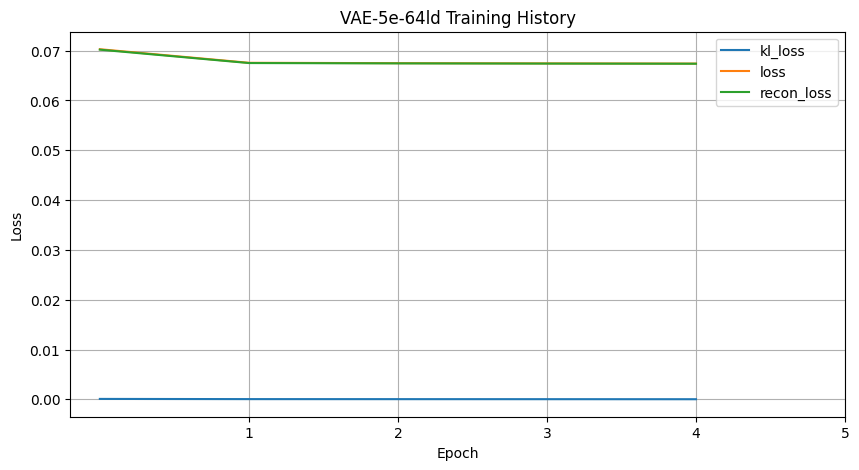

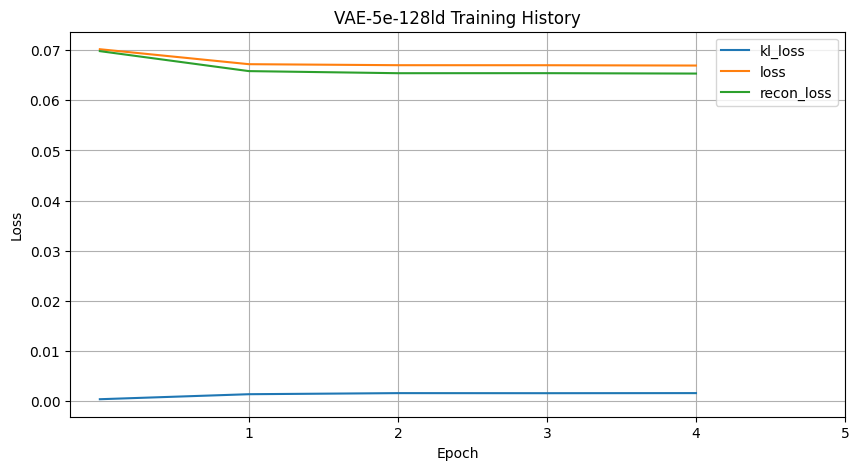

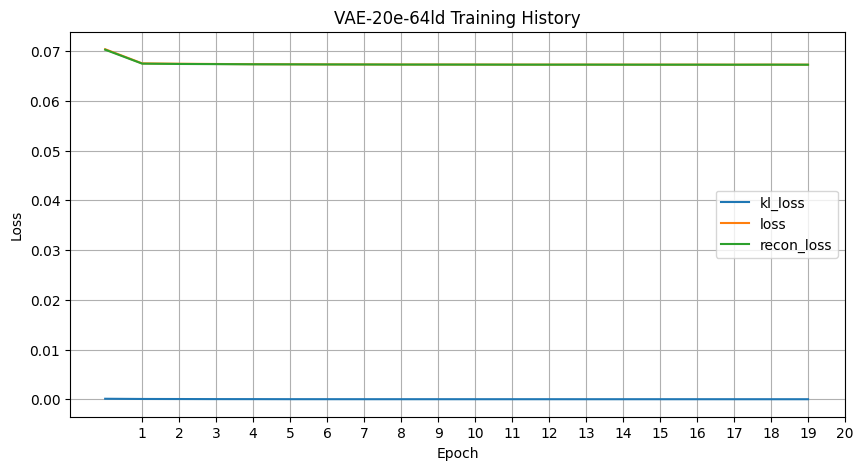

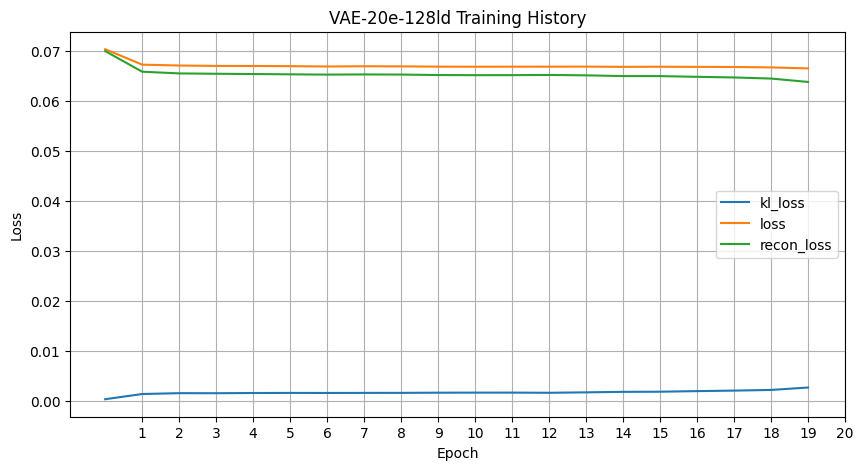

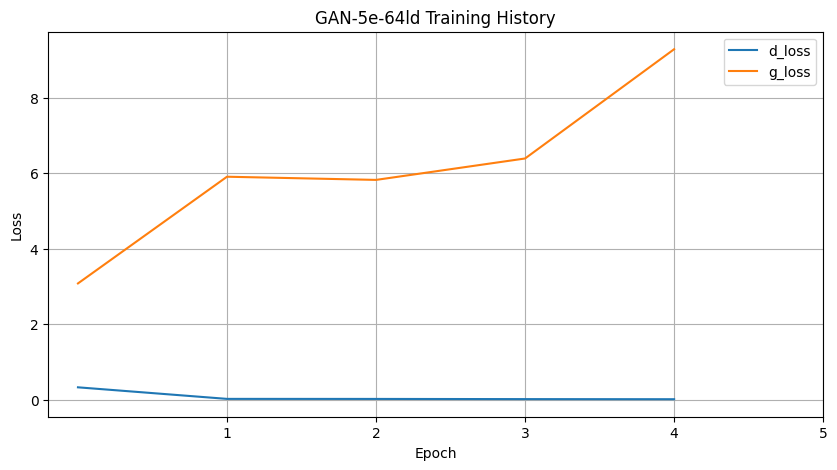

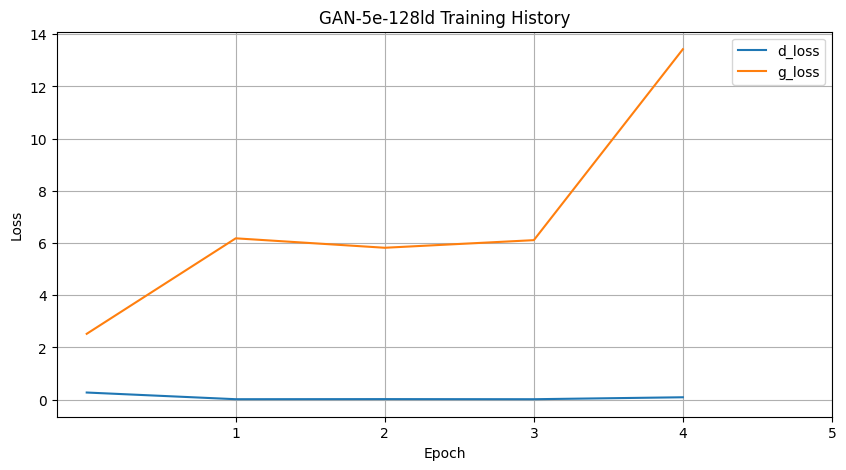

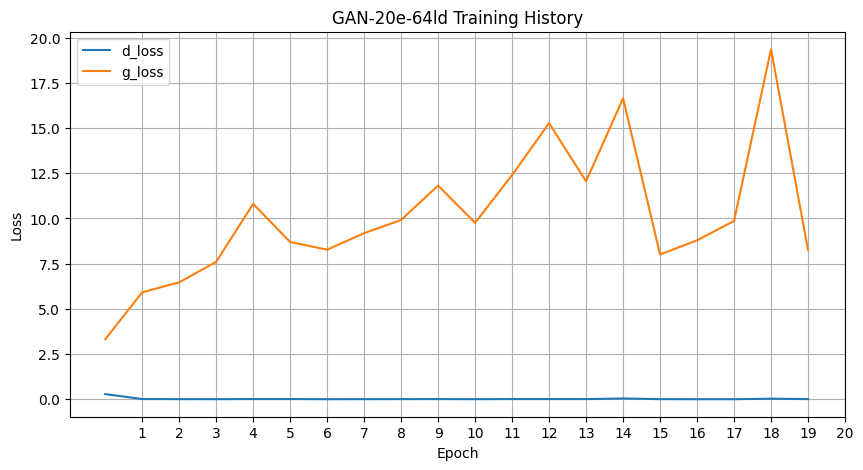

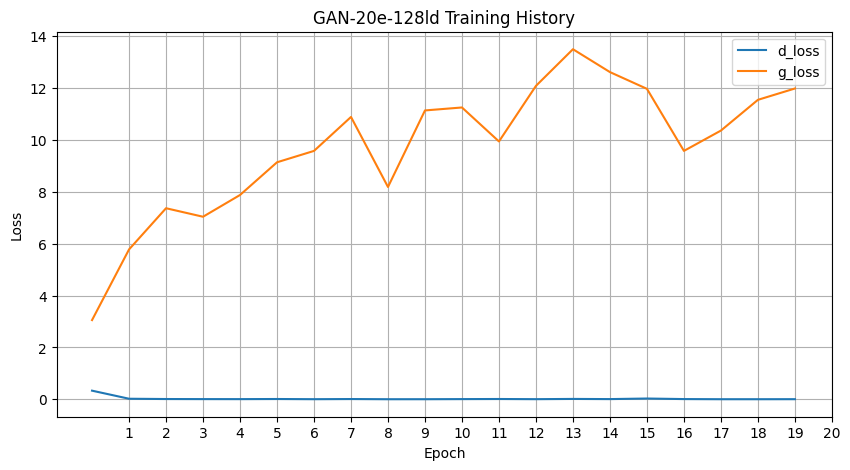

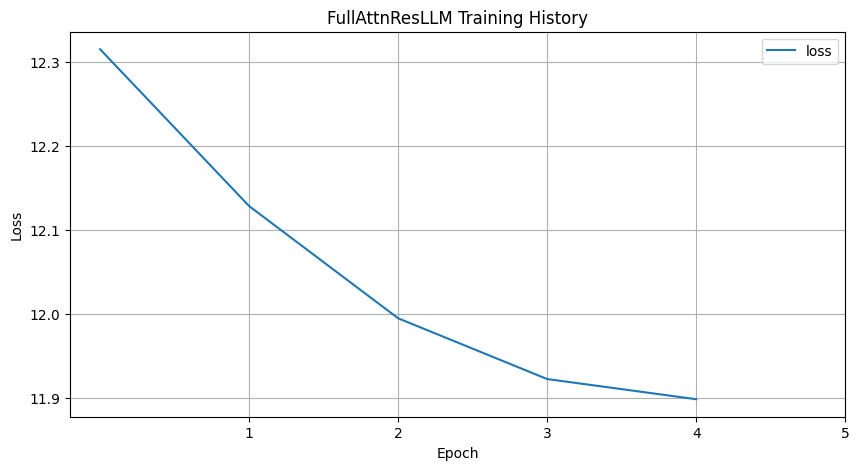

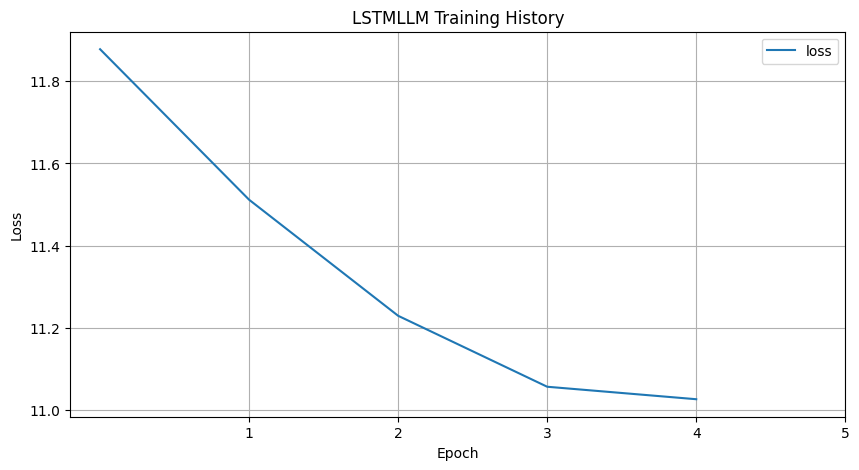

In [15]:
# 16. Visualisasi Loss

# 16.1. Visualisasi Loss Training Image
for exp_name, result in histories.items():
    history = result['history']
    history.plot(title=f"{exp_name} Training History")
    
# 17.2. Visualisasi Loss Training Text
attnres_history.plot(title="FullAttnResLLM Training History")
lstm_history.plot(title="LSTMLLM Training History")


### 17. Perbandingan Hasil
#### 17.1. Perbandingan Hasil Gambar
| Model | Kualitas gambar | Stabilitas training | Loss | Kemudahan implementasi | Apakah model menghasilkan data baru atau hanya merekonstruksi? |
|-|-|-|-|-|-|
| VAE-5e-64ld | Sedang, gambar blur dan halus, semua sampel sangat mirip satu sama lain (low diversity), bentuk digit "9" terlihat namun tidak tajam | Sangat stabil, loss turun cepat lalu plateau sejak epoch 1 | `recon_loss ≈ 0.067`, `kl_loss ≈ 0` (hampir posterior collapse) | Mudah, satu optimizer, satu loss function | Menghasilkan data **baru** via sampling `z ~ N(0, I)` pada latent space, bukan merekonstruksi gambar input |
| VAE-5e-128ld | Sedang, sedikit lebih bervariasi dibanding 64ld, detail sedikit lebih tajam di beberapa sampel | Stabil, loss dan recon_loss turun perlahan dan konsisten | `recon_loss ≈ 0.065`, `kl_loss ≈ 0.001-0.002` (mulai aktif) | Mudah | Menghasilkan data **baru** |
| VAE-20e-64ld | Sedang, hasil hampir identik dengan VAE-5e-64ld; epoch tambahan tidak memberikan peningkatan signifikan karena posterior collapse | Stabil tapi plateau sangat awal (epoch 1), tidak ada penurunan berarti setelahnya | `recon_loss ≈ 0.067` (flat), `kl_loss ≈ 0` (posterior collapse) | Mudah | Menghasilkan data **baru** |
| VAE-20e-128ld | Lebih baik, gambar lebih tajam, diversity sedikit lebih tinggi, beberapa sampel menunjukkan variasi bentuk "9" yang lebih kaya | Stabil, tren penurunan recon_loss berlanjut perlahan hingga epoch 20 | `recon_loss ≈ 0.064-0.066`, `kl_loss` naik perlahan ≈ 0.002 (regularisasi mulai bekerja) | Mudah | Menghasilkan data **baru** |
| GAN-5e-64ld | Buruk, gambar berbentuk tapi penuh artefak kotak-kotak, semua sampel sangat mirip (mode collapse) | Tidak stabil, `d_loss` kolaps ke ~0 di epoch 1, `g_loss` naik terus hingga ~9 | `d_loss ≈ 0`, `g_loss ≈ 9` | Sedang, perlu menyeimbangkan dua optimizer secara bersamaan | Menghasilkan data **baru** (tapi terbatas akibat mode collapse) |
| GAN-5e-128ld | Buruk, lebih noisy dan acak dibanding 64ld, pola tidak terbentuk dengan jelas | Tidak stabil, `d_loss ≈ 0`, `g_loss` melonjak hingga ~13 di epoch 4 | `d_loss ≈ 0`, `g_loss ≈ 13` | Sedang | Menghasilkan data **baru** (tapi tidak variatif) |
| GAN-20e-64ld | Sedang, shape mulai terbentuk menyerupai satu pola tertentu, namun semua sampel hampir identik (mode collapse parah) | Sangat tidak stabil, `g_loss` berosilasi besar antara ~8 dan ~19 sepanjang training | `d_loss ≈ 0`, `g_loss` osilasi antara 8-19 | Sedang | Menghasilkan data **baru** (tapi hanya satu mode) |
| GAN-20e-128ld | Sedang, shape vertikal terbentuk menyerupai siluet, namun repetitif dan kurang detail | Tidak stabil, `g_loss` naik dan berfluktuasi, `d_loss ≈ 0` | `d_loss ≈ 0`, `g_loss ≈ 10-13` | Sedang | Menghasilkan data **baru** (tapi terbatas) |


#### 17.2. Perbandingan Hasil Teks
| Model | Kualitas kalimat | Koherensi teks | Repetisi kata | Kesalahan grammar | Pengaruh panjang prompt | Waktu Training |
|-|-|-|-|-|-|-|
| Full-Attention-Residual Transformer | Sangat buruk, token yang dihasilkan mayoritas berasal dari bahasa asing (Malayalam, Swahili, Azerbaijani, dll.) yang tidak berkaitan dengan prompt Bahasa Indonesia | Sangat rendah, tidak ada hubungan semantik antara token yang dihasilkan; output tidak membentuk kalimat bermakna | Rendah dalam hal kata yang sama diulang, namun token yang muncul acak dan tidak bermakna dalam konteks | Sangat banyak, output bukan kalimat valid sama sekali | Prompt lebih panjang menghasilkan sedikit lebih banyak token output, namun kualitas tidak meningkat; model belum mampu memanfaatkan konteks panjang | Lebih lambat per epoch dibanding LSTM karena komputasi attention residual antar layer yang kompleks; loss akhir ≈ 11.9 |
| LSTM | Buruk, model hampir hanya mengulang kembali seluruh isi prompt tanpa menambahkan konten bermakna | Sangat rendah, tidak ada generasi teks baru yang koheren; output berupa echo dari prompt ditambah tanda baca atau satu token asing | Sangat tinggi, output = prompt + koma berulang (`,,,,,`) atau satu token asing kemudian berhenti | Ada, namun terbatas, output sangat pendek sehingga kesalahan grammar tidak terlalu terekspos | Prompt lebih panjang menyebabkan model lebih banyak meng-echo isi prompt tanpa menghasilkan teks baru yang bermakna | Lebih cepat per epoch dibanding FullAttnResLLM; loss akhir ≈ 11.0 (lebih rendah) |


### 18. Analisis

**1. Apa perbedaan model generatif dan model klasifikasi?**

Model **klasifikasi** belajar memetakan input ke label/kategori diskrit, yaitu memodelkan probabilitas kondisional `P(y|x)` (misal: gambar -> "kucing" atau "anjing"). Model **generatif** sebaliknya belajar distribusi data `P(x)` itu sendiri agar mampu menghasilkan sampel baru yang serupa dengan data pelatihan. Model generatif tidak membutuhkan label, tujuannya bukan mengenali data, melainkan menciptakan data baru yang realistis.

---

**2. Model vision generatif apa yang digunakan?**

Dua model digunakan:
- **VAE (Variational Autoencoder)**, model berbasis encoder-decoder dengan regularisasi probabilistik pada latent space.
- **GAN (Generative Adversarial Network)**, model berbasis dua jaringan yang saling berkompetisi: Generator vs Discriminator.

---

**3. Rumus utama apa yang digunakan pada model vision tersebut?**

**VAE** menggunakan ELBO (Evidence Lower Bound) sebagai loss:

```
L_VAE = L_recon + L_KL

L_recon = MSE(x, x_hat)
        = || x - x_hat ||^2

L_KL    = -0.5 * mean(1 + log(sigma^2) - mu^2 - sigma^2)
        = D_KL( q(z|x) || p(z) )
```

Proses reparameterization trick untuk membuat sampling bisa di-backprop:

```
z = mu + eps * sigma,   eps ~ N(0, I)
```

**GAN** menggunakan adversarial loss berbasis Binary Cross-Entropy:

```
L_D = BCE(D(x),    1)        <-- real images dianggap label 1
    + BCE(D(G(z)), 0)        <-- fake images dianggap label 0

L_G = BCE(D(G(z)), 1)        <-- generator ingin D menganggap fake sebagai real
```

---

**4. Bagaimana model menghasilkan gambar baru?**

**VAE:**
1. Sample vektor laten acak dari prior: `z ~ N(0, I)` dengan dimensi `latent_dim`
2. Lewatkan z melalui decoder: `x_hat = decoder(z)`
3. Output diresize ke bentuk gambar `(1, 28, 28)`

Karena latent space terstruktur dan kontinu (dipaksa mendekati Gaussian oleh KL loss), titik z yang berbeda menghasilkan gambar yang berbeda namun masih realistis.

**GAN:**
1. Sample noise acak: `z ~ N(0, I)` dengan dimensi `latent_dim`
2. Lewatkan z melalui Generator: `fake = G(z)`
3. Generator telah belajar (selama training melawan Discriminator) untuk mengubah noise menjadi gambar yang realistis

---

**5. Apa fungsi latent vector atau noise?**

**Latent vector (VAE):** Merupakan representasi tersembunyi (compressed) dari data dalam ruang dimensi rendah yang terstruktur. Setiap dimensi pada latent space idealnya mengkodekan fitur semantik tertentu dari gambar. Karena latent space dipaksa mendekati distribusi Gaussian oleh KL loss, kita bisa menyample titik mana pun di ruang tersebut dan mendapatkan gambar yang valid. Titik berbeda di latent space -> gambar berbeda.

**Noise z (GAN):** Berfungsi sebagai "benih keacakan" yang menjadi bahan baku Generator. Generator belajar fungsi transformasi `G: z -> x` yang memetakan distribusi noise sederhana `N(0,I)` ke distribusi data yang kompleks. Dengan menyample z yang berbeda, Generator menghasilkan gambar yang bervariasi.

---

**6. Apakah hasil gambar sudah menyerupai data asli?**

**VAE:** Cukup menyerupai, semua sampel menghasilkan digit yang dapat dikenali sebagai "9" (kemungkinan besar MNIST digit 9). Namun gambar masih **blur/halus** karena MSE loss cenderung menghasilkan rata-rata piksel daripada detail tajam. Diversity antar sampel juga rendah akibat posterior collapse (kl_loss ≈ 0 pada VAE-64ld), artinya latent space tidak dimanfaatkan secara penuh.

**GAN:** Kurang menyerupai data asli. Semua konfigurasi mengalami **mode collapse** (d_loss -> 0, g_loss -> ∞), sehingga Generator hanya menghasilkan satu pola yang diulang-ulang dan tidak mampu merepresentasikan keragaman distribusi data asli. Secara keseluruhan, VAE jauh lebih stabil dan menghasilkan output yang lebih dapat dikenali dibanding GAN pada eksperimen ini.

---

**7. Model text generatif apa yang digunakan?**

Dua model digunakan:
- **FullAttnResLLM**, Transformer dengan mekanisme Full Attention Residuals, di mana setiap layer dapat mengakses output semua layer sebelumnya melalui attention weighting. Berdasarkan arsitektur dari arXiv:2603.15031.
- **LSTMLLM**, Language model berbasis LSTM (Long Short-Term Memory) yang memproses sequence token secara recurrent.

Keduanya menggunakan **pretrained embedder** (`LazarusNLP/all-indo-e5-small-v4`) dengan projection ke dimensi internal model.

---

**8. Rumus utama apa yang digunakan pada model text tersebut?**

Keduanya menggunakan **Cross-Entropy Loss** untuk prediksi token berikutnya:

```
L = - sum_t [ log P(token_{t+1} | token_{1..t}) ]
  = CrossEntropy(logits, target_ids)
```

**FullAttnResLLM** tambahan menggunakan:

Self-Attention standar:
```
Attn(Q, K, V) = softmax( Q K^T / sqrt(d_k) ) * V
```

Attention Residual Mixing antar layer (menggabungkan output semua layer sebelumnya):
```
alpha = softmax( K_layers * q_pseudo )
h     = sum_i ( alpha_i * V_i )
```

RMS Normalization:
```
RMSNorm(x) = x / ( sqrt(mean(x^2)) + eps ) * weight
```

**LSTMLLM** menggunakan persamaan LSTM:
```
f_t = sigmoid( W_f [h_{t-1}, x_t] )    <-- forget gate
i_t = sigmoid( W_i [h_{t-1}, x_t] )    <-- input gate
g_t = tanh(    W_g [h_{t-1}, x_t] )    <-- cell gate
o_t = sigmoid( W_o [h_{t-1}, x_t] )    <-- output gate

c_t = f_t * c_{t-1} + i_t * g_t        <-- cell state
h_t = o_t * tanh(c_t)                  <-- hidden state
```

---

**9. Bagaimana model memprediksi kata atau karakter berikutnya?**

Proses generasi berjalan secara **autoregresif** melalui langkah-langkah berikut:

1. Tokenisasi prompt input menggunakan tokenizer pretrained
2. Encode token menjadi embedding melalui `embedder.encode_tokens(input_ids)`
3. Lewatkan embedding melalui forward pass model (Transformer atau LSTM) -> `hidden`
4. Proyeksikan hidden state ke distribusi vocabulary melalui `embedder.decode_logits(hidden)` -> `logits`
5. Ambil logits token terakhir dan terapkan **Temperature Scaling**:

```
logits_scaled = logits[:, -1, :] / temperature
```

6. Terapkan **Top-K Filtering**, hanya pertahankan K token dengan probabilitas tertinggi:

```
values, indices = topk(logits_scaled, k=50)
probs = softmax(values)
```

7. Lakukan **Multinomial Sampling**:

```
next_token = multinomial(probs, num_samples=1)
```

8. Append token baru ke sequence, ulangi dari langkah 2 hingga max_length atau EOS token

---

**10. Apa pengaruh panjang prompt terhadap output?**

Berdasarkan hasil generation yang dilampirkan:

- **Prompt pendek (1 kalimat):** Model LSTM hampir tidak menghasilkan token baru sama sekali. FullAttnResLLM menghasilkan beberapa token asing namun tidak koheren.
- **Prompt sedang (1-2 kalimat):** Sedikit lebih banyak token dihasilkan, namun kualitas tidak meningkat.
- **Prompt panjang (1 paragraf penuh):** LSTM lebih banyak meng-echo prompt itu sendiri lalu berhenti atau menambahkan tanda baca. FullAttnResLLM menghasilkan lebih banyak token tambahan namun tetap tidak koheren.

Secara teoritis, prompt lebih panjang memberikan konteks yang lebih kaya untuk model memprediksi token berikutnya. Namun karena kedua model **undertrained** (hanya 5 epoch, data terbatas), konteks panjang tersebut belum dapat dimanfaatkan secara efektif. Perlu diperhatikan pula bahwa `context_size` di kode membatasi jumlah token yang dijadikan konteks saat inference, sehingga prompt yang melebihi `context_size` akan terpotong.

---

**11. Mengapa hasil text generation kadang berulang atau tidak masuk akal?**

Ada beberapa penyebab utama:

- **Undertraining:** Hanya 5 epoch dengan korpus terbatas, model belum cukup belajar pola distribusi bahasa yang valid. Loss akhir ≈ 11 masih sangat tinggi untuk language modeling yang baik.
- **Vocabulary mismatch:** Embedder `all-indo-e5-small-v4` dilatih pada data multibahasa, sehingga token dari berbagai bahasa (Malayalam, Swahili, Azerbaijani, Telugu, dll.) memiliki representasi dalam vocabulary. Karena model belum belajar distribusi yang tepat, token asing tersebut tersample secara acak.
- **LSTM echo problem:** LSTM tanpa mekanisme attention memiliki keterbatasan dalam memodelkan dependensi jangka panjang. Pada data yang sedikit, pola paling "aman" yang dipelajari model adalah mengulang token input, karena itulah LSTM cenderung meng-echo prompt.
- **Top-K sampling dengan distribusi datar:** Ketika model belum konvergen, distribusi probabilitas antar token relatif datar (tidak ada token yang jauh lebih probable), sehingga sampling menjadi sangat acak.
- **Repetisi tanda baca (LSTM):** Model belajar bahwa koma dan titik sering muncul sebagai terminator kalimat, sehingga ketika distribusi tidak informatif, model jatuh ke pola ini.

---

**12. Apa kesulitan utama saat training model generatif?**

**GAN:**
- Keseimbangan antara Generator (G) dan Discriminator (D) sangat sulit dijaga. Jika D terlalu kuat, `d_loss -> 0` dan G tidak mendapat gradient yang berguna -> **mode collapse**.
- Terlihat jelas pada semua konfigurasi GAN: `d_loss` kolaps ke ~0 sejak epoch pertama, dan `g_loss` terus naik tanpa konvergensi.
- Tidak ada loss tunggal yang merepresentasikan kualitas gambar secara langsung.

**VAE:**
- **Posterior collapse:** KL term mendekati 0 berarti encoder mengabaikan input dan z hanya belajar dari prior. Decoder tidak memanfaatkan latent space secara penuh -> output menjadi kurang variatif.
- Ini terjadi pada VAE-5e-64ld dan VAE-20e-64ld di mana `kl_loss ≈ 0` sepanjang training.
- MSE loss sebagai reconstruction loss menghasilkan output yang blur (rata-rata piksel), bukan detail tajam.

**LLM:**
- Membutuhkan data sangat besar dan training yang sangat lama. Dengan data terbatas dan hanya 5 epoch, model tidak mampu belajar distribusi bahasa yang bermakna.
- Vocabulary size yang besar membuat cross-entropy loss sulit turun ke nilai yang menghasilkan prediksi berkualitas.

---

**13. Apakah loss kecil selalu berarti output generasi bagus?**

**Tidak.** Contoh dari hasil eksperimen ini:

- **VAE (posterior collapse):** `recon_loss ≈ 0.067` terlihat kecil, namun `kl_loss ≈ 0` menandakan model "curang" dengan mengabaikan latent variable -> output kurang variatif meskipun loss rendah.
- **GAN (mode collapse):** `d_loss ≈ 0` terlihat seperti "Discriminator sempurna", padahal ini justru tanda kegagalan, Discriminator terlalu dominan sehingga Generator gagal total dan hanya menghasilkan satu pola.
- **LLM:** Loss turun konsisten dari ≈11.9 ke ≈11.0, namun output masih tidak koheren karena skala loss tersebut masih jauh dari konvergensi yang menghasilkan teks berkualitas.

Loss adalah **proxy** untuk kualitas, bukan jaminan. Evaluasi kualitatif pada sampel yang dihasilkan tetap diperlukan, dan dalam kasus GAN, metrik seperti FID (Fréchet Inception Distance) lebih representatif daripada nilai loss.

---

**14. Apa perbedaan generasi gambar dan generasi teks?**

| Aspek | Generasi Gambar | Generasi Teks |
|-|-|-|
| **Ruang output** | Kontinu, nilai piksel dalam rentang [0, 1] | Diskrit, token dipilih dari vocabulary berukuran tetap |
| **Struktur data** | Spasial 2D (lebar × tinggi × channel) | Sekuensial 1D (token berurutan) |
| **Proses sampling** | Langsung dari distribusi kontinu (Gaussian untuk VAE, transformasi noise untuk GAN) | Sampling dari distribusi kategoris via softmax -> multinomial |
| **Dependency antar elemen** | Piksel bertetangga memiliki korelasi spasial lokal maupun global | Token memiliki dependensi jangka panjang (konteks kalimat/paragraf) |
| **Evaluasi kualitas** | Dapat dievaluasi visual secara langsung; metrik: FID, IS | Memerlukan penilaian semantik dan linguistik; metrik: perplexity, BLEU |
| **Ukuran output** | Fixed size (28×28 = 784 piksel) | Variable length (autoregresif hingga EOS atau max_length) |

---

**15. Bagian kode mana yang berhubungan dengan rumus loss?**

**VAE**, method `compute_loss` di class `VAE`:
```python
# Reconstruction Loss: L_recon = MSE(x, x_hat)
recon_loss = F.mse_loss(x_hat, x)

# KL Divergence: L_KL = -0.5 * mean(1 + log(sigma^2) - mu^2 - sigma^2)
kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

total_loss = recon_loss + kl_loss
```

**GAN**, method `discriminator_loss` dan `generator_loss` di class `GAN`:
```python
# Discriminator Loss
real_loss = self.criterion(real_preds, real_labels)   # BCE(D(x), 1)
fake_loss = self.criterion(fake_preds, fake_labels)   # BCE(D(G(z)), 0)
d_loss = real_loss + fake_loss

# Generator Loss
g_loss = self.criterion(fake_preds, real_labels)      # BCE(D(G(z)), 1)
```
Criterion yang digunakan: `nn.BCEWithLogitsLoss()`

**FullAttnResLLM & LSTMLLM**, method `compute_loss` di masing-masing class:
```python
# Cross-Entropy Loss: L = -sum log P(token_target | context)
loss = F.cross_entropy(
    logits.reshape(-1, logits.size(-1)),
    target_ids.reshape(-1),
    ignore_index=self.embedder.tokenizer.pad_token_id
)
```

---

**16. Bagian kode mana yang berhubungan dengan proses sampling atau generation?**

**VAE**, method `generate` di class `VAE`:
```python
# Sample dari prior: z ~ N(0, I)
z = torch.randn(num_samples, self.latent_dim, device=self.device)

# Decode latent vector menjadi gambar
samples = self.decode(z)
samples = samples.view(num_samples, *self.image_shape)
```

**GAN**, method `generate` di class `GAN` -> memanggil `generate_fake`:
```python
# Sample noise acak
z = torch.randn(num_samples, self.latent_dim, device=self.device)

# Generator mengubah noise menjadi gambar: fake = G(z)
samples = self.generate_fake(z)
samples = samples.view(num_samples, *self.image_shape)
```

**FullAttnResLLM & LSTMLLM**, method `generate` di class `BaseTextGenerator`:
```python
for _ in range(max_length):
    input_ids = generated[:, -context_size:]
    input_emb = self.embedder.encode_tokens(input_ids)

    hidden  = self.forward(input_emb)
    logits  = self.embedder.decode_logits(hidden)

    # Temperature Scaling: logits / temperature
    next_token_logits = logits[:, -1, :] / temperature

    # Top-K Filtering: ambil K token terbesar
    values, indices = torch.topk(next_token_logits, top_k)
    probs = F.softmax(values, dim=-1)

    # Multinomial Sampling: token ~ Multinomial(p)
    sampled    = torch.multinomial(probs, num_samples=1)
    next_token = indices.gather(-1, sampled)

    generated = torch.cat([generated, next_token], dim=1)
```


### 17. Kesimpulan

### 17.1. VAE, Stabil tetapi Terjebak pada Output yang Homogen dan Blur

VAE berhasil menghasilkan gambar yang dapat dikenali sebagai digit "9" pada seluruh konfigurasi
yang diuji. Namun demikian, keberhasilan tersebut datang dengan dua kelemahan mendasar yang
konsisten muncul di semua eksperimen.

**Pertama, posterior collapse.** Pada konfigurasi VAE-5e-64ld dan VAE-20e-64ld, nilai `kl_loss`
mendekati 0 sepanjang training. Ini berarti encoder berhenti memanfaatkan latent space secara
bermakna, decoder belajar menghasilkan gambar "rata-rata" tanpa bergantung pada variasi z.
Akibatnya, meskipun gambar terlihat menyerupai digit, seluruh 20 sampel yang dihasilkan tampak
hampir identik. Menambah epoch dari 5 ke 20 pada latent_dim 64 tidak memberikan perbaikan
apapun, kurva loss plateau sejak epoch pertama dan tidak bergerak lagi.

**Kedua, output cenderung blur.** Penggunaan MSE sebagai reconstruction loss mendorong decoder
untuk menghasilkan rata-rata piksel, bukan detail yang tajam. Hasilnya adalah gambar yang
smooth dan halus, tetapi kehilangan tekstur dan ketajaman tepi yang dimiliki data asli.

Konfigurasi terbaik adalah **VAE-20e-128ld**, satu-satunya konfigurasi di mana `kl_loss`
menunjukkan tren naik secara konsisten (latent space mulai dimanfaatkan), dan sampel yang
dihasilkan memiliki sedikit lebih banyak variasi bentuk. Hal ini menunjukkan bahwa latent
dimension yang lebih besar membantu mencegah posterior collapse, dan training lebih lama
memberikan waktu yang cukup bagi KL term untuk aktif bekerja.

**Kesimpulan VAE:** VAE adalah pilihan yang stabil dan mudah diimplementasikan, tetapi
tanpa teknik tambahan seperti KL annealing atau penggunaan loss perceptual, hasilnya akan
cenderung blur dan tidak variatif, terutama ketika latent dimension terlalu kecil.

---

### 17.2. GAN, Potensi Lebih Tinggi tetapi Gagal Konvergen pada Eksperimen Ini

GAN secara teoritis mampu menghasilkan gambar yang lebih tajam dan realistis dibanding VAE
karena Generator dilatih oleh sinyal adversarial dari Discriminator, bukan oleh MSE.
Namun pada seluruh konfigurasi yang diuji, GAN **gagal mencapai keseimbangan yang diperlukan.**

Pola yang sama terjadi di semua konfigurasi: `d_loss` kolaps mendekati 0 sejak epoch pertama,
sementara `g_loss` terus naik tanpa batas. Ini adalah tanda klasik **mode collapse**, 
Discriminator terlalu cepat mendominasi, sehingga Generator tidak mendapat gradient yang
berguna untuk belajar. Tanpa sinyal yang informatif, Generator akhirnya "menyerah" dan hanya
menghasilkan satu pola yang diulang-ulang pada seluruh sampel.

Perbandingan antar konfigurasi menunjukkan bahwa **menambah epoch memperparah masalah**, bukan
memperbaikinya. GAN-20e-64ld memiliki `g_loss` yang berosilasi ekstrem antara 8 hingga 19,
jauh lebih tidak stabil dibanding GAN-5e-64ld. Artinya, training lebih lama hanya
memperdalam ketidakstabilan yang sudah ada sejak awal, bukan menuju konvergensi.

Dari sisi output visual, GAN-20e-64ld dan GAN-20e-128ld memang menghasilkan shape yang lebih
terdefinisi dibanding konfigurasi 5 epoch, ada satu bentuk yang konsisten muncul. Namun
konsistensi ini bukan bukti kualitas, melainkan bukti mode collapse yang semakin parah:
Generator hanya mampu menghasilkan satu jenis gambar.

**Kesimpulan GAN:** Arsitektur GAN sederhana (fully connected, tanpa Batch Normalization,
tanpa teknik stabilisasi seperti gradient penalty atau label smoothing) sangat rentan terhadap
mode collapse. Pada dataset dan setup seperti ini, GAN bukan pilihan yang tepat tanpa modifikasi
arsitektur yang signifikan.

---

### 17.3. Perbandingan VAE vs GAN, Stabilitas vs Potensi

| | VAE | GAN |
|-|-|-|
| **Kestabilan training** | Tinggi, loss turun monoton | Rendah, d_loss kolaps, g_loss divergen |
| **Kualitas gambar** | Sedang, dapat dikenali tapi blur | Buruk pada eksperimen ini, mode collapse |
| **Variasi output** | Rendah, sampel sangat homogen | Sangat rendah, hanya satu mode |
| **Kemudahan implementasi** | Mudah, satu optimizer, satu loss | Sulit, dua optimizer, perlu keseimbangan |
| **Potensi teoritis** | Terbatas oleh blur dari MSE loss | Lebih tinggi jika training berhasil stabil |

Pada kondisi eksperimen ini (arsitektur sederhana, epoch terbatas), VAE secara keseluruhan
memberikan hasil yang lebih berguna dibanding GAN, meskipun keduanya masih jauh dari
menghasilkan gambar yang benar-benar berkualitas tinggi.

---

### 17.4. LSTM, Echo Machine yang Belum Belajar Menghasilkan Teks Baru

LSTMLLM menunjukkan kurva training yang sehat, loss turun konsisten dari ~11.9 ke ~11.0 dalam
5 epoch, bahkan lebih baik dari FullAttnResLLM. Namun hasil generasi teks mengungkapkan
kenyataan yang berbeda: model hampir tidak menghasilkan token baru sama sekali.

Pada prompt pendek (4-5 kata), LSTM hanya mengembalikan prompt itu sendiri tanpa tambahan
apapun. Pada prompt panjang (1 paragraf), LSTM meng-echo seluruh isi prompt lalu menambahkan
tanda baca berulang (`,,,,,`) atau satu token asing, kemudian berhenti. Ini menunjukkan bahwa
model belum belajar pola sekuens yang berada **di luar** distribusi token dalam data training.

Masalah ini bersumber dari kombinasi dua hal: data training yang terlalu sedikit dan epoch
yang terlalu singkat, serta keterbatasan arsitektur LSTM sendiri dalam menangkap dependensi
jangka panjang. LSTM memproses sekuens secara recurrent, sehingga informasi dari token-token
awal dapat "terlupakan" sebelum sampai ke prediksi token berikutnya, masalah yang dikenal
sebagai **vanishing gradient** pada sekuens panjang.

**Kesimpulan LSTM:** LSTM dapat belajar (loss turun), tetapi belum cukup belajar untuk
*menghasilkan* teks baru yang bermakna. Pada kondisi ini, LSTM lebih berfungsi sebagai
pengulang prompt daripada sebagai generator bahasa.

---

### 17.5. FullAttnResLLM, Arsitektur Lebih Canggih, tetapi Hasilnya Lebih Kacau

FullAttnResLLM memiliki arsitektur yang lebih kompleks dibanding LSTM, mekanisme Full
Attention Residuals memungkinkan setiap layer mengakses output semua layer sebelumnya,
secara teoritis memberikan kemampuan yang lebih kuat dalam menangkap konteks jangka panjang.

Namun pada eksperimen ini, FullAttnResLLM justru menghasilkan teks yang **lebih buruk secara
kualitatif** dibanding LSTM. Alih-alih mengulang prompt, model ini menghasilkan token-token
dari berbagai bahasa yang tidak berkaitan (Malayalam, Swahili, Azerbaijani, Telugu, dll.)
yang tersebar acak setelah prompt berakhir. Loss akhirnya pun lebih tinggi (~11.9) dibanding
LSTM (~11.0).

Ini terjadi karena kompleksitas arsitektur membutuhkan lebih banyak data dan lebih banyak
waktu training untuk konvergen. Dengan data dan epoch yang sama, model yang lebih kompleks
tidak selalu menang, ia justru bisa lebih "bingung" karena parameter yang lebih banyak belum
mendapat cukup sinyal untuk belajar distribusi yang tepat.

Token multibahasa yang muncul menunjukkan bahwa embedder (`all-indo-e5-small-v4`) memiliki
vocabulary yang mencakup banyak bahasa, dan model belum belajar untuk "memilih" token Bahasa
Indonesia secara konsisten dari distribusi yang luas tersebut.

**Kesimpulan FullAttnResLLM:** Arsitektur yang lebih canggih tidak menjamin hasil yang lebih
baik ketika data dan epoch tidak memadai. Kompleksitas tambahan justru memperlambat konvergensi
dan menghasilkan output yang lebih acak dibanding model yang lebih sederhana.

---

### 17.6. Loss Kecil Bukan Jaminan Kualitas Generasi

Eksperimen ini secara konsisten menunjukkan bahwa nilai loss tidak dapat dijadikan satu-satunya
indikator kualitas hasil generasi:

- **VAE:** `recon_loss` kecil (≈0.067) tetapi output blur dan tidak variatif karena
  `kl_loss ≈ 0` (posterior collapse). Model "curang" dengan mengabaikan latent space.
- **GAN:** `d_loss ≈ 0` terlihat sangat baik, padahal ini justru tanda kegagalan total
  (mode collapse). Generator tidak mendapat sinyal yang berguna.
- **LSTM:** Loss turun paling signifikan, tetapi outputnya hanya mengulang prompt, model
  belajar sesuatu, tapi bukan yang kita inginkan.
- **FullAttnResLLM:** Loss lebih tinggi dari LSTM, namun outputnya justru lebih kacau,
  lebih banyak token asing yang tidak bermakna.

Kualitas generasi harus dinilai dari aspek yang tidak tertangkap oleh angka loss semata:
**variasi output, koherensi semantik, kemiripan visual dengan data asli, dan keterbacaan teks.**
Dalam praktik, dibutuhkan metrik evaluasi tambahan seperti FID (untuk gambar), Perplexity,
atau BLEU (untuk teks) agar penilaian lebih objektif.

---

### 17.7. Kesimpulan Keseluruhan

Dari seluruh eksperimen yang dilakukan, diperoleh beberapa pelajaran penting:

1. **VAE lebih stabil dari GAN** pada kondisi arsitektur sederhana dan training terbatas,
   tetapi hasilnya blur dan tidak variatif tanpa teknik tambahan (KL annealing, perceptual loss).

2. **GAN memiliki potensi lebih besar** untuk menghasilkan gambar tajam, tetapi sangat sulit
   distabilkan tanpa modifikasi arsitektur (Batch Normalization, gradient penalty, label
   smoothing). Pada eksperimen ini GAN gagal total karena mode collapse.

3. **Epoch lebih banyak tidak selalu membantu**, pada VAE-64ld, 20 epoch tidak memberikan
   perbaikan apapun karena posterior collapse terjadi sejak awal. Pada GAN, epoch lebih banyak
   justru memperparah ketidakstabilan.

4. **Latent dimension lebih besar** (128 vs 64) memberikan manfaat nyata pada VAE, membantu
   mencegah posterior collapse dan menghasilkan output yang sedikit lebih variatif dan tajam.

5. **LSTM dan FullAttnResLLM keduanya gagal menghasilkan teks bermakna** pada kondisi ini,
   bukan karena arsitekturnya salah, tetapi karena data dan epoch training jauh di bawah
   kebutuhan minimum untuk language modeling yang fungsional.

6. **Arsitektur yang lebih kompleks tidak selalu lebih baik** dengan sumber daya terbatas.
   LSTM yang lebih sederhana mencapai loss lebih rendah, sementara FullAttnResLLM yang lebih
   kompleks justru menghasilkan output yang lebih acak.

7. **Loss kecil bukan jaminan kualitas**, evaluasi kualitatif pada sampel yang dihasilkan
   tetap wajib dilakukan, karena angka loss tidak selalu mencerminkan koherensi, variasi,
   maupun kemiripan dengan data asli.
